In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from pandas.plotting import autocorrelation_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import sys
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import xgboost as xgb
from xgboost import XGBRegressor

plt.style.use('ggplot')


APPLE_PATH = "apple.csv"
MSFT_PATH  = "microsoft.csv"

In [8]:
def load_revenue_timeseries_csv(csv_path: str, row_name="Revenue from Business Activities - Total"):
    df = pd.read_csv(csv_path)

    # строка с датами
    field_row_idx = df.index[df.iloc[:, 0].astype(str).str.strip().eq("Field Name")][0]
    date_labels = df.iloc[field_row_idx, 1:].tolist()

    # строка с Revenue Total
    metric_row_idx = df.index[df.iloc[:, 0].astype(str).str.contains(row_name, case=False, na=False)][0]
    values = df.iloc[metric_row_idx, 1:].tolist()

    ts = pd.DataFrame({"date_raw": date_labels, "revenue_raw": values})

    ts["revenue_raw"]=ts["revenue_raw"].astype(str).str.replace(',', '')

    ts["date"] = pd.to_datetime(ts["date_raw"], dayfirst=True, errors="coerce")
    ts["revenue"] = pd.to_numeric(ts["revenue_raw"], errors="coerce")

    ts = ts[["date", "revenue"]].dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
    return ts


In [10]:
apple_ts = load_revenue_timeseries_csv(APPLE_PATH)
apple_ts["company"] = "Apple"

msft_ts = load_revenue_timeseries_csv(MSFT_PATH)
msft_ts["company"] = "Microsoft"

data = pd.concat([apple_ts, msft_ts], ignore_index=True)

data.head(), data.tail()


(        date   revenue company
 0 2007-12-29  10430000   Apple
 1 2008-03-29   7980000   Apple
 2 2008-06-28   7561000   Apple
 3 2008-09-27  11520000   Apple
 4 2008-12-27  11880000   Apple,
           date   revenue    company
 139 2024-06-30  64727000  Microsoft
 140 2024-09-30  65585000  Microsoft
 141 2024-12-31  69632000  Microsoft
 142 2025-03-31  70066000  Microsoft
 143 2025-06-30  76441000  Microsoft)

In [12]:
print("Missing revenue rows:", data["revenue"].isna().sum())

dups = data.duplicated(subset=["company", "date"]).sum()
print("Duplicates (company,date):", dups)

data = data.drop_duplicates(subset=["company", "date"]).sort_values(["company", "date"]).reset_index(drop=True)

for c in data["company"].unique():
    tmp = data[data["company"] == c].sort_values("date")
    diffs = tmp["date"].diff().value_counts().head(5)
    print("\n", c, "top date diffs:")
    print(diffs)


Missing revenue rows: 0
Duplicates (company,date): 0

 Apple top date diffs:
date
91 days    68
98 days     3
Name: count, dtype: int64

 Microsoft top date diffs:
date
92 days    35
91 days    23
90 days    13
Name: count, dtype: int64


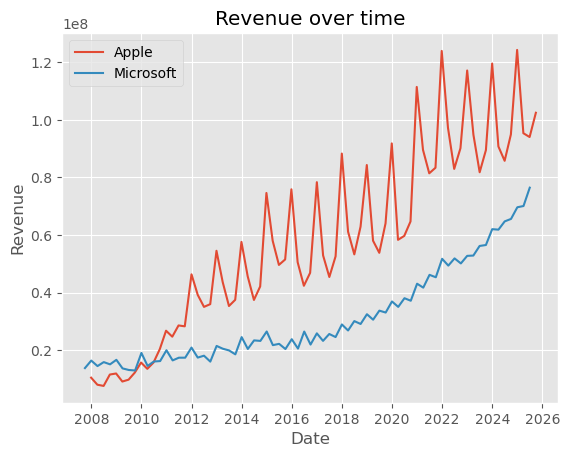

In [14]:
plt.figure()
for c in data["company"].unique():
    tmp = data[data["company"] == c].sort_values("date")
    plt.plot(tmp["date"], tmp["revenue"], label=c)

plt.title("Revenue over time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.show()


In [16]:
def add_iqr_outlier_flag(df_one_company):
    x = df_one_company["revenue"].dropna()
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    
    out = df_one_company.copy()
    out["is_outlier_iqr"] = (out["revenue"] < low) | (out["revenue"] > high)
    return out, (low, high)

checked = []
bounds = {}
for c in data["company"].unique():
    tmp = data[data["company"] == c].sort_values("date")
    tmp2, (low, high) = add_iqr_outlier_flag(tmp)
    checked.append(tmp2)
    bounds[c] = (low, high)

data_qc = pd.concat(checked).reset_index(drop=True)

bounds, data_qc[data_qc["is_outlier_iqr"]].head()


({'Apple': (-37502000.0, 157984000.0), 'Microsoft': (-17044000.0, 77504000.0)},
 Empty DataFrame
 Columns: [date, revenue, company, is_outlier_iqr]
 Index: [])

In [18]:
def baseline_forecast_one_company(ts, test_size=8, ma_window=4):
    ts = ts.sort_values("date").reset_index(drop=True).copy()
    ts = ts.dropna(subset=["revenue"])

    if len(ts) <= test_size + ma_window:
        raise ValueError("Too few points for chosen test_size/ma_window")

    train = ts.iloc[:-test_size].copy()
    test  = ts.iloc[-test_size:].copy()

    # Naive forecast
    last_train = train["revenue"].iloc[-1]
    test["pred_naive"] = last_train

    # Moving average forecast
    ma_value = train["revenue"].iloc[-ma_window:].mean()
    test["pred_ma"] = ma_value

    return train, test

def mae(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.sqrt(np.mean((y_true - y_pred)**2))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    eps = 1e-9
    return np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100


### Data Preparation & Baseline Summary
Мы извлекли показатель Revenue (Revenue from Business Activities - Total) и преобразовали данные в формат временного ряда (date, revenue). Даты приведены к типу datetime и отсортированы по времени, выполнена проверка пропусков и дубликатов. Дополнительно отмечены потенциальные выбросы по правилу IQR (как диагностический флаг, без автоматического удаления).

### Baseline Forecasting
В качестве базовых моделей использованы:
1) Naive forecast — прогноз равен последнему значению train;
2) Moving Average — прогноз равен среднему последних k наблюдений train (k=4).
Качество оценено на последних N наблюдениях (test) с метриками MAE, RMSE, MAPE. Добавлены графики Actual vs Forecast для каждой компании.


**Exploratory Time Series Analysis - Aiya**

In [20]:
data

,date,revenue,company
0,2007-12-29,10430000,Apple
1,2008-03-29,7980000,Apple
2,2008-06-28,7561000,Apple
3,2008-09-27,11520000,Apple
4,2008-12-27,11880000,Apple
...,...,...,...
139,2024-06-30,64727000,Microsoft
140,2024-09-30,65585000,Microsoft
141,2024-12-31,69632000,Microsoft
142,2025-03-31,70066000,Microsoft


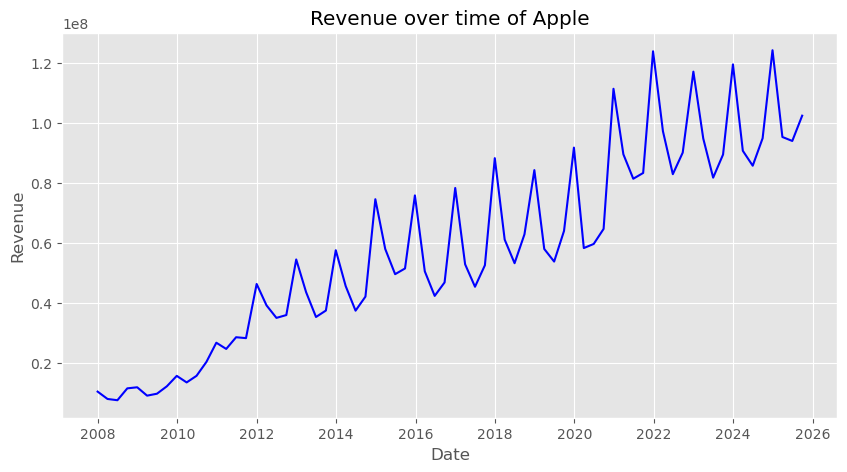

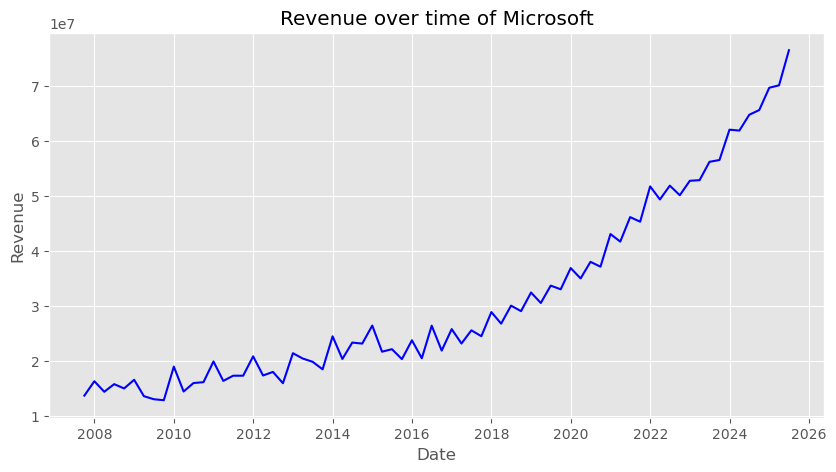

In [22]:
for company in data["company"].unique():
    ts=data[data["company"]==company].sort_values("date")
    plt.figure(figsize=(10,5))
    plt.plot(ts["date"], ts["revenue"], color="blue")
    plt.title(f"Revenue over time of {company}")
    plt.xlabel("Date")
    plt.ylabel("Revenue")
    plt.grid(True)
    plt.show()

The graph of the Revenue time series shows a difference in the growth between Apple and Microsoft.

Apple's revenue shows faster and more pronounced growth over time.
At the same time, the series is characterized by high volatility: Revenue values
often experience sharp rises and falls, and the amplitude of fluctuations
increases over time.

In contrast, Microsoft's revenue is growing more moderately and
shows smoother dynamics without sudden jumps.

In [24]:
for company in data["company"].unique():
    ts = data[data["company"]==company]["revenue"]
    print(f"{company}:")
    print(ts.describe())


Apple:
count    7.200000e+01
mean     5.824418e+07
std      3.194652e+07
min      7.561000e+06
25%      3.580525e+07
50%      5.416050e+07
75%      8.467675e+07
max      1.243000e+08
Name: revenue, dtype: float64
Microsoft:
count    7.200000e+01
mean     3.132404e+07
std      1.684351e+07
min      1.292000e+07
25%      1.841150e+07
50%      2.452850e+07
75%      4.204850e+07
max      7.644100e+07
Name: revenue, dtype: float64


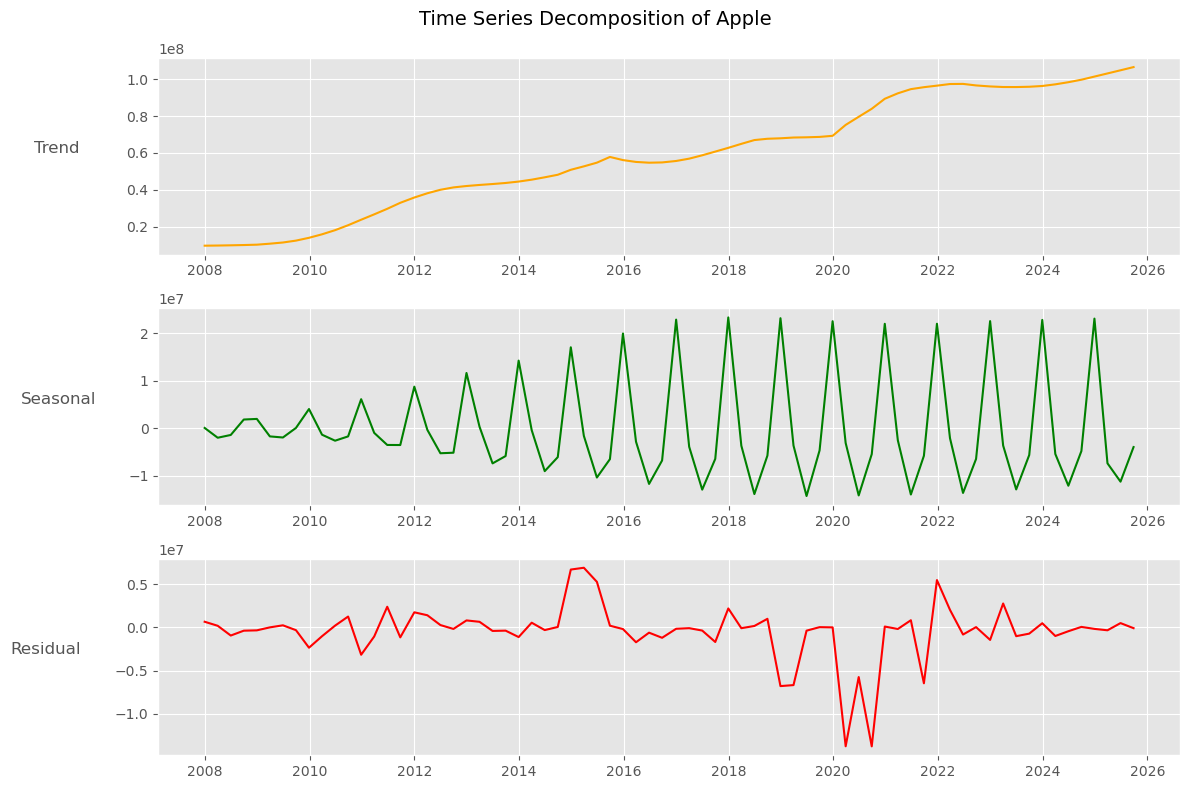

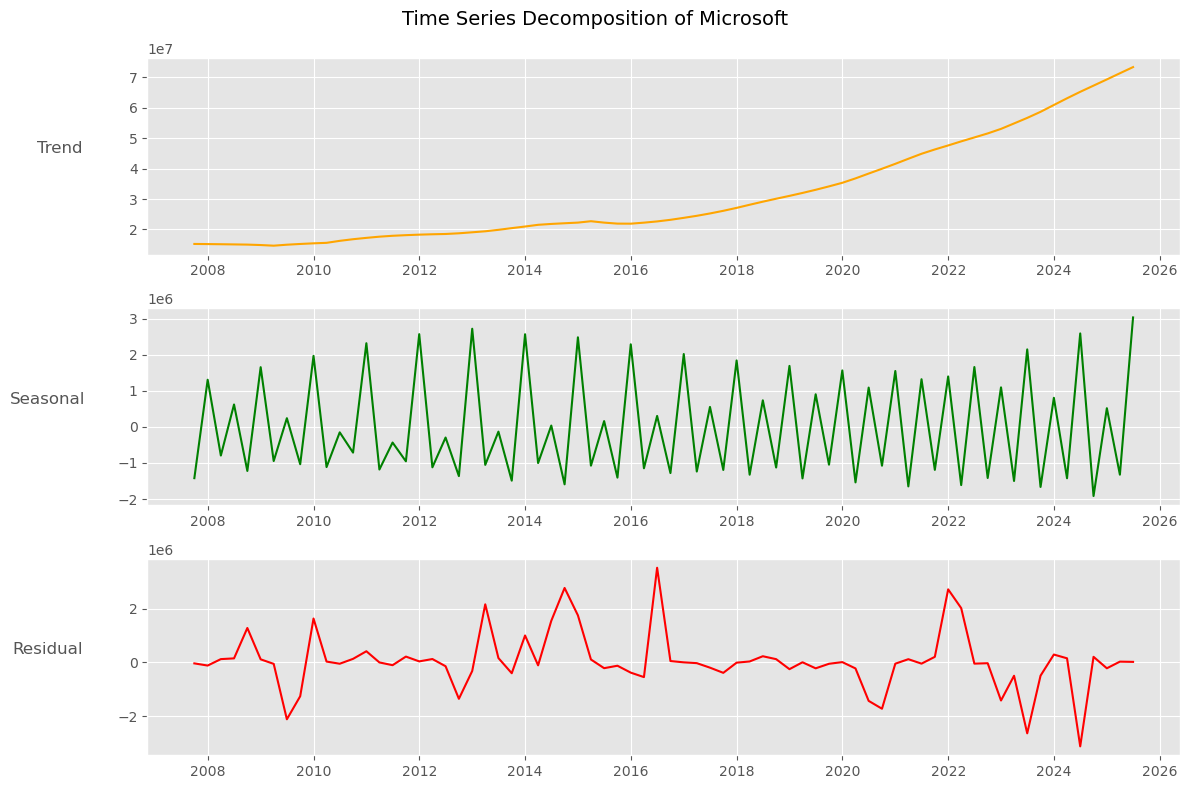

In [26]:
for company in data["company"].unique():
    ts=(
        data[data["company"]==company]
        .sort_values("date")
        .set_index("date")["revenue"]
        .dropna()
    )

    stl=STL(
        ts,
        period=4,
        robust=True
    )
    result=stl.fit()
    
    fig,axes = plt.subplots(3, 1, figsize=(12, 8))

    axes[0].plot(result.trend, label="Trend", color="orange")
    axes[0].set_ylabel("Trend", rotation=0, labelpad=50, va="center")
    axes[0].yaxis.set_label_position("left")

    axes[1].plot(result.seasonal, label="Seasonal", color="green")
    axes[1].set_ylabel("Seasonal", rotation=0, labelpad=50, va="center")
    axes[1].yaxis.set_label_position("left")

    axes[2].plot(result.resid, label="Residual", color="red")
    axes[2].set_ylabel("Residual", rotation=0, labelpad=50, va="center")
    axes[2].yaxis.set_label_position("left")

    plt.suptitle(f"Time Series Decomposition of {company}", fontsize=14)
    plt.tight_layout()
    plt.show()

ts-an attribute with sorted and cleaned values by date

#### Trend

**Apple:** Growth pattern: slow start (2007-2010), rapid acceleration (2010-2015), stabilization after 2020

**Microsoft:** Steady **upward linear trend**, accelerating after 2014 (cloud services expansion)

#### Seasonality

Both companies show **strong quarterly seasonality**

**Apple:** Regular fluctuations with **increasing amplitude** 

**Microsoft:** Quarterly seasonality with **more stable amplitude**


#### Residuals

**Apple:** Notable anomalies: 2015-2016, 2020 COVID-19, 2021-2022 

**Microsoft:** Main anomaly: 2024-2025

We can use non-linear models (Random Forest, Gradient Boosting) for future predictions


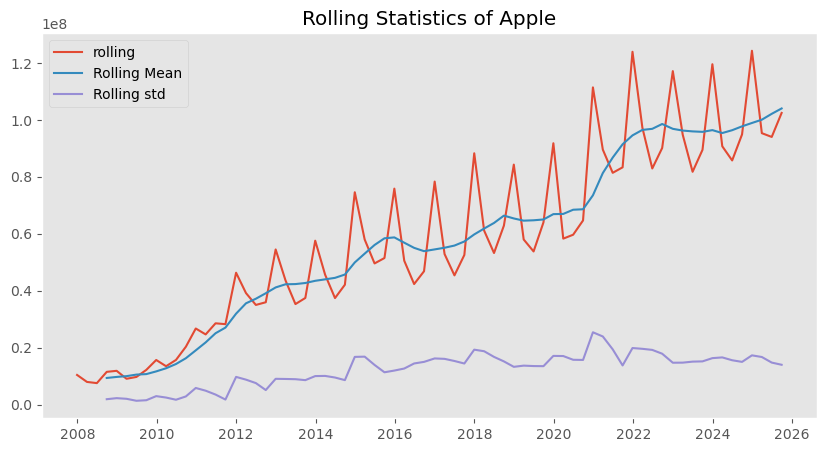

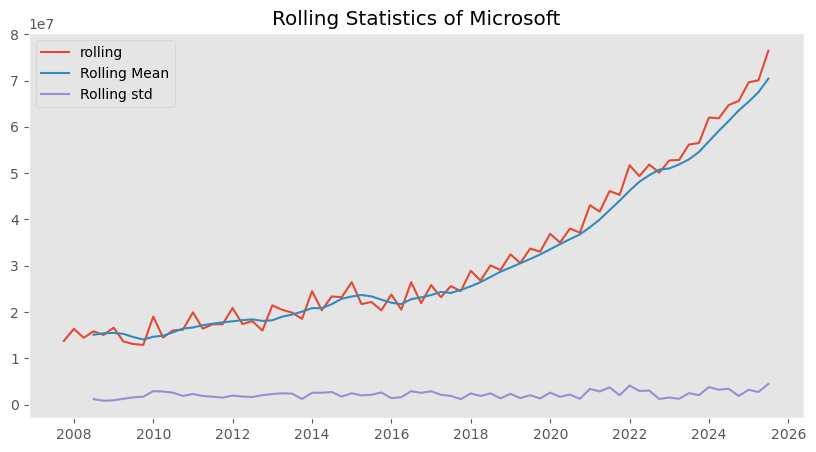

In [28]:
window = 4
for company in data["company"].unique():
    ts=(
        data[data["company"]==company]
        .sort_values("date")
        .set_index("date")["revenue"]
        .dropna()
    )
    rolling_mean=ts.rolling(window).mean()
    rolling_std=ts.rolling(window).std()

    plt.figure(figsize=(10,5))
    plt.plot(ts, label="rolling")
    plt.plot(rolling_mean,label="Rolling Mean")
    plt.plot(rolling_std,label="Rolling std")
    plt.title(f"Rolling Statistics of {company}")
    plt.legend()
    plt.grid()
    plt.show()

**Rolling statistics** is a technique that calculates the average of a specific subset of data points ("window") and moves this window forward sequentially to detect changes or anomalies over time.  

#### Rolling Mean

The rolling mean smooths out seasonal fluctuations and highlights the underlying trend. For Apple, it starts slowly in early years and accelerates after 2010, then continues rising. For Microsoft, the rolling mean demonstrates steady linear growth throughout the period, with consistent upward movement and no dramatic changes in growth rate.

#### Rolling Std

The rolling standard deviation measures the magnitude of fluctuations around the trend. Apple's rolling std increases significantly over time, rising from near zero in 2008 to approximately 0.2 by 2025. This growing volatility reflects larger absolute fluctuations as Revenue scales up. This pattern shows that Apple experiences significant fluctuations from quarter to quarter, likely driven by product launch cycles and seasonal consumer demand.

Microsoft's rolling std, in contrast, remains relatively low and stable throughout the entire period. This indicates much lower std compared to Apple. The stability suggests that Microsoft's revenue streams are more predictable, which is consistent with their subscription-based enterprise business model.

#### Implications

The rolling statistics analysis confirms that Apple and Microsoft have fundamentally different revenue characteristics. Apple exhibits higher growth rates but also higher volatility, making it more challenging to forecast with narrow confidence intervals. Microsoft shows more moderate but stable growth, which should allow for more precise predictions. These insights will inform our approach to feature engineering and model selection in subsequent analysis stages.

In [30]:
window = 4
for company in data["company"].unique():
    ts = data[data["company"]==company]["revenue"]
    last_mean = ts.tail(window).mean()
    last_std = ts.tail(window).std()
    
    print(f"{company}: Rolling mean = {last_mean:,.0f}, std = {last_std:,.0f}")


Apple: Rolling mean = 104,040,250, std = 14,004,581
Microsoft: Rolling mean = 70,431,000, std = 4,486,106


Apple demonstrates more than **3x higher volatility** compared to Microsoft, confirming our visual analysis

In [32]:
for company in data_qc["company"].unique():
    ts = data_qc[data_qc["company"]==company]
    n_outliers = ts["is_outlier_iqr"].sum()
    total = len(ts)
    print(f"{company}: {n_outliers} outliers ({n_outliers/total:.1%})")


Apple: 0 outliers (0.0%)
Microsoft: 0 outliers (0.0%)


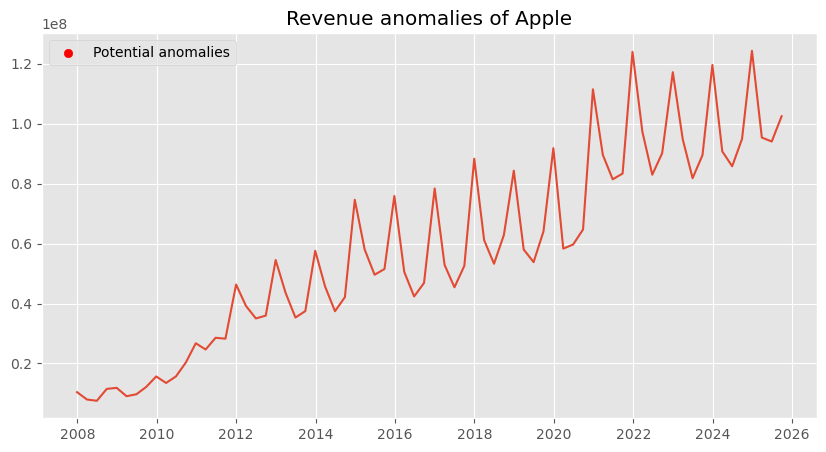

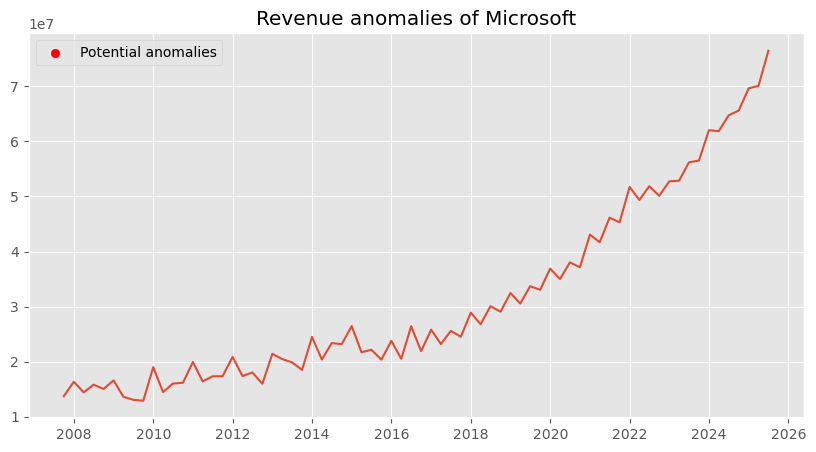

In [34]:
for company in data_qc["company"].unique():
    ts = data_qc[data_qc["company"]==company].sort_values("date")
    plt.figure(figsize=(10,5))
    plt.plot(ts["date"], ts["revenue"])
    plt.scatter(
        ts.loc[ts["is_outlier_iqr"], "date"],
        ts.loc[ts["is_outlier_iqr"], "revenue"],
        color="red",
        label="Potential anomalies"
    )
    plt.title(f"Revenue anomalies of {company}")
    plt.legend()
    plt.grid(True)
    plt.show()


During the analysis, no statistical outliers were detected for either Apple or Microsoft using the IQR method.

This **does not mean** that the time series is perfect or does not contain strong fluctuations. It only shows that even the highest quarterly revenue values fall within the normal range of variation for each company.
Therefore, the data does not require removing extreme values. Instead, it is important to **properly model** the seasonal component when building forecasting models.

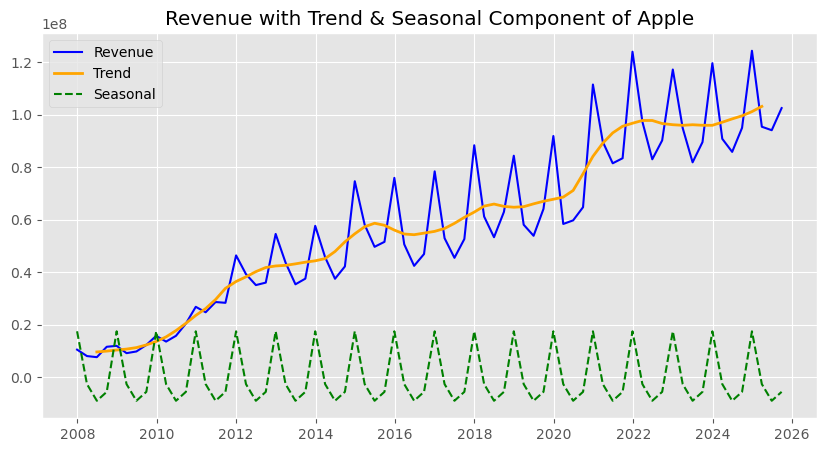

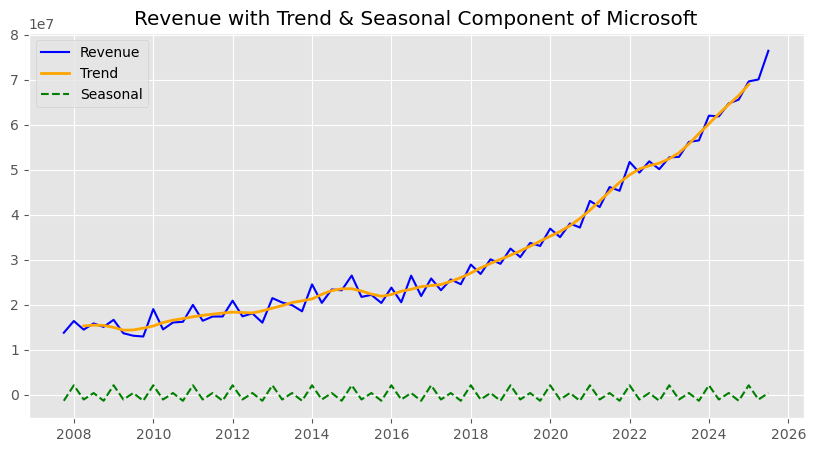

In [36]:
for company in data["company"].unique():
    ts=data_qc[data_qc["company"]==company].sort_values("date").set_index("date")["revenue"]
    decomposition=seasonal_decompose(
        ts,
        model="additive",
        period=4
    )
    plt.figure(figsize=(10,5))
    plt.plot(ts, label="Revenue", color="blue")
    plt.plot(decomposition.trend, label="Trend", color="orange", linewidth=2)
    plt.plot(decomposition.seasonal, label="Seasonal", color="green", linestyle="--")
    plt.title(f"Revenue with Trend & Seasonal Component of {company}")
    plt.legend()
    plt.grid(True)
    plt.show()

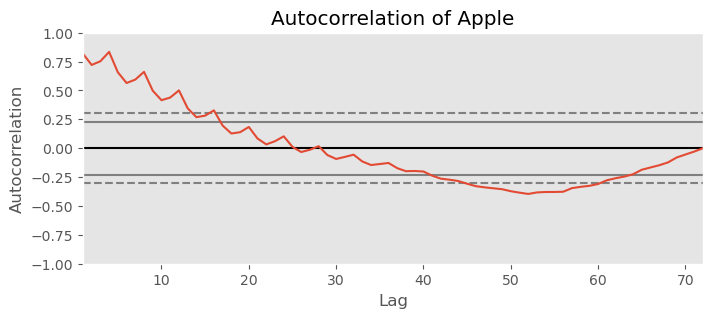

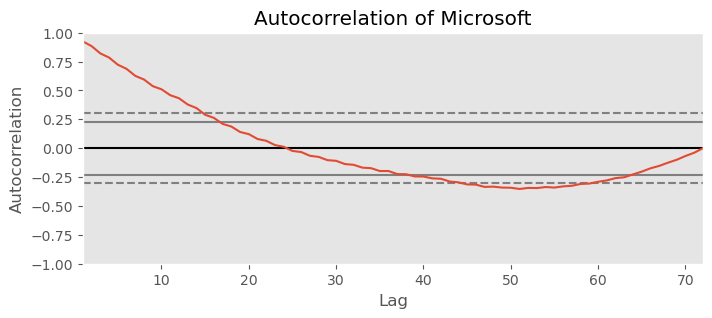

In [38]:
for company in data["company"].unique():
    ts=data_qc[data_qc["company"]==company].sort_values("date").set_index("date")["revenue"]
    plt.figure(figsize=(8,3))
    autocorrelation_plot(ts)
    plt.title(f"Autocorrelation of {company}")
    plt.show()

Both time series demonstrate a strong dependence on past values. However, this dependence appears to be slightly weaker for Microsoft. This can be explained by its lower volatility and the absence of sharp seasonal peaks that are clearly observed in Apple’s revenue.

In [40]:
for company in data["company"].unique():
    ts = data[data["company"]==company]["revenue"]
    growth = ts.pct_change() * 100
    print(f"{company}'s Average growth: {growth.mean():.2f}%, Max growth: {growth.max():.2f}%")


Apple's Average growth: 6.88%, Max growth: 77.10%
Microsoft's Average growth: 3.27%, Max growth: 47.23%


To quantitatively evaluate the companies’ development, the quarterly revenue growth rate (QoQ Growth) was calculated.

**Apple** demonstrates a more aggressive growth model. Its average quarterly growth rate is approximately twice compared to Microsoft.
The high maximum growth value (77.1%) indicates successful product launches and strong seasonal demand.

**Microsoft** shows more stable but slower growth. The lower average growth rate and less pronounced peaks suggest a more mature business structure and more predictable cash flows.

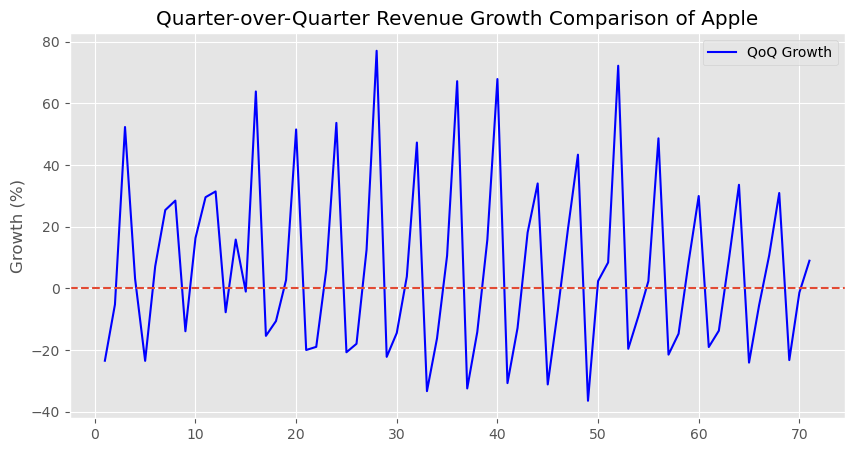

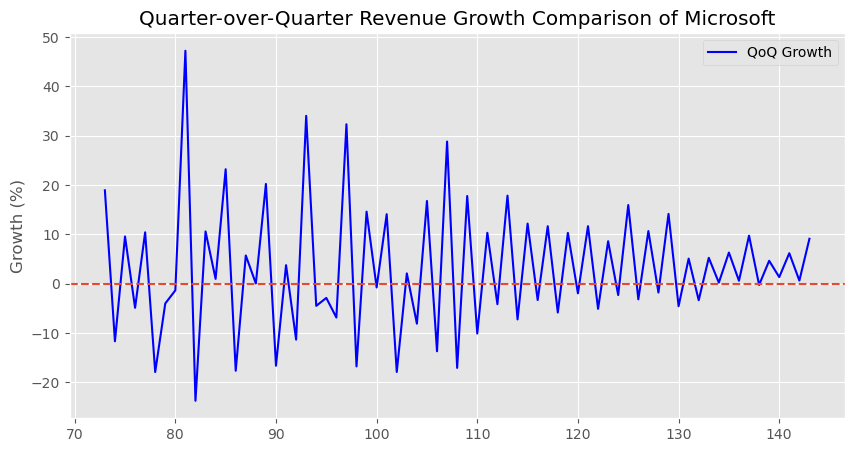

In [42]:
for company in data["company"].unique():
    ts=data[data["company"]==company]["revenue"]
    growth = ts.pct_change() * 100
    plt.figure(figsize=(10,5))
    plt.plot(growth, label="QoQ Growth", color="blue")
    plt.axhline(0, linestyle="--")
    plt.title(f"Quarter-over-Quarter Revenue Growth Comparison of {company}")
    plt.ylabel("Growth (%)")
    plt.legend()
    plt.grid(True)
    plt.show()

In [44]:
data.head()


,date,revenue,company
0,2007-12-29,10430000,Apple
1,2008-03-29,7980000,Apple
2,2008-06-28,7561000,Apple
3,2008-09-27,11520000,Apple
4,2008-12-27,11880000,Apple


In [46]:
from statsmodels.tsa.stattools import adfuller
import numpy as np

def check_stationarity(ts, company_name):
    
    ts_log = np.log(ts)
    
    result = adfuller(ts_log.dropna())
    p_value = result[1]
    
    print(f"\n{company_name}")
    print(f"ADF p-value: {p_value}")
    
    if p_value > 0.05:
        print("Not stationary → applying first differencing")
        ts_diff = ts_log.diff().dropna()
        
        result_diff = adfuller(ts_diff)
        print(f"After differencing p-value: {result_diff[1]}")
        
    else:
        print("Already stationary")
        ts_diff = ts_log
    
    return ts_log, ts_diff


In [48]:
def plot_acf_pacf(ts_diff, company_name, lags=12):
    plt.figure(figsize=(12,5))
    plot_acf(ts_diff, lags=lags)
    plt.title(f"ACF of {company_name} (Differenced Log Revenue)")
    plt.show()
    
    plt.figure(figsize=(12,5))
    plot_pacf(ts_diff, lags=lags, method="ywm")  # метод Yule-Walker
    plt.title(f"PACF of {company_name} (Differenced Log Revenue)")
    plt.show()



Apple
ADF p-value: 0.057317306647142865
Not stationary → applying first differencing
After differencing p-value: 0.1440527688396271


<Figure size 1200x500 with 0 Axes>

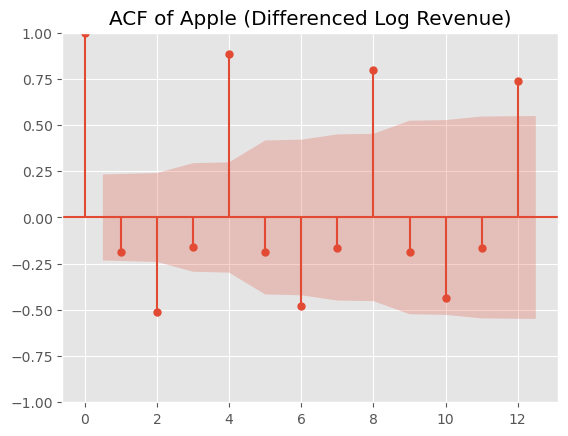

<Figure size 1200x500 with 0 Axes>

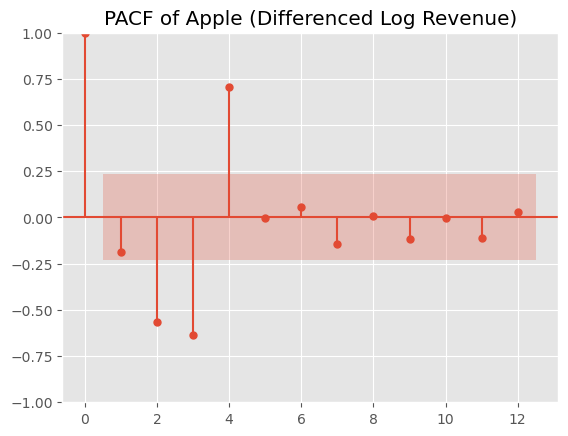


Microsoft
ADF p-value: 0.9990187735233517
Not stationary → applying first differencing
After differencing p-value: 0.6385398279311184


<Figure size 1200x500 with 0 Axes>

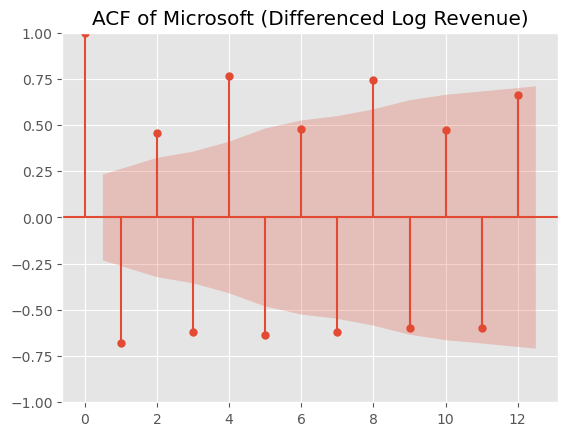

<Figure size 1200x500 with 0 Axes>

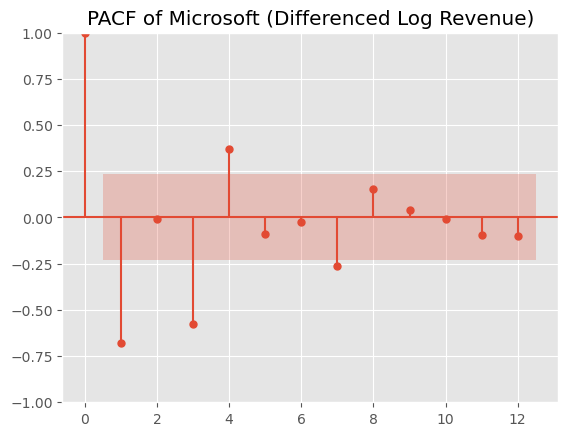

In [50]:
for company in data["company"].unique():
    ts = data[data["company"]==company].sort_values("date").set_index("date")["revenue"]
    ts_log, ts_diff = check_stationarity(ts, company)
    plot_acf_pacf(ts_diff, company)


In [52]:
def adf_test(series, name=""):
    result = adfuller(series)
    
    print(f"\nADF Test for {name}")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value}")


In [54]:
for company in data["company"].unique():
    
    ts = (
        data[data["company"] == company]
        .sort_values("date")
        .set_index("date")["revenue"]
        .dropna()
    )
    
    adf_test(ts, company)



ADF Test for Apple
ADF Statistic: -0.8795793691259898
p-value: 0.7946228249296758
Critical Values:
   1%: -3.5319549603840894
   5%: -2.905755128523123
   10%: -2.5903569458676765

ADF Test for Microsoft
ADF Statistic: 3.344723169842506
p-value: 1.0
Critical Values:
   1%: -3.5443688564814813
   5%: -2.9110731481481484
   10%: -2.5931902777777776


<Figure size 1200x500 with 0 Axes>

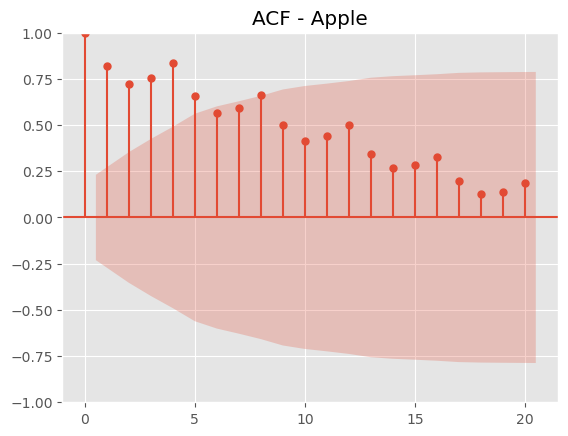

<Figure size 1200x500 with 0 Axes>

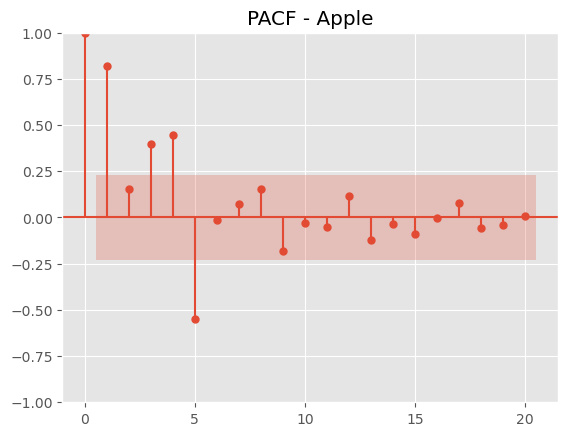

<Figure size 1200x500 with 0 Axes>

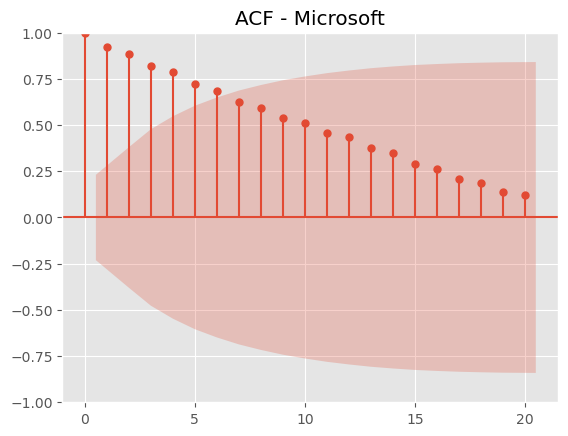

<Figure size 1200x500 with 0 Axes>

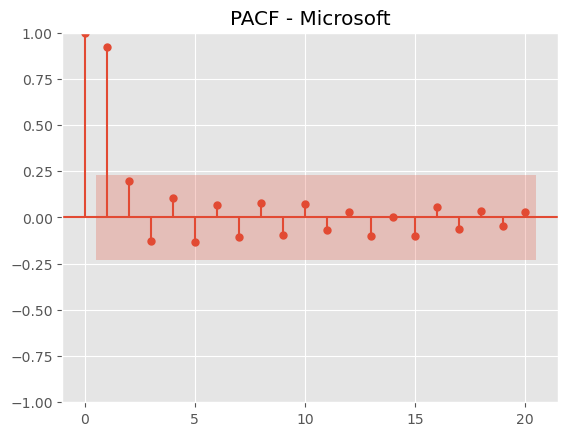

In [56]:
for company in data["company"].unique():
    
    ts = (
        data[data["company"] == company]
        .sort_values("date")
        .set_index("date")["revenue"]
        .dropna()
    )
    
    plt.figure(figsize=(12,5))
    plot_acf(ts, lags=20)
    plt.title(f"ACF - {company}")
    plt.show()
    
    plt.figure(figsize=(12,5))
    plot_pacf(ts, lags=20, method='ywm')
    plt.title(f"PACF - {company}")
    plt.show()


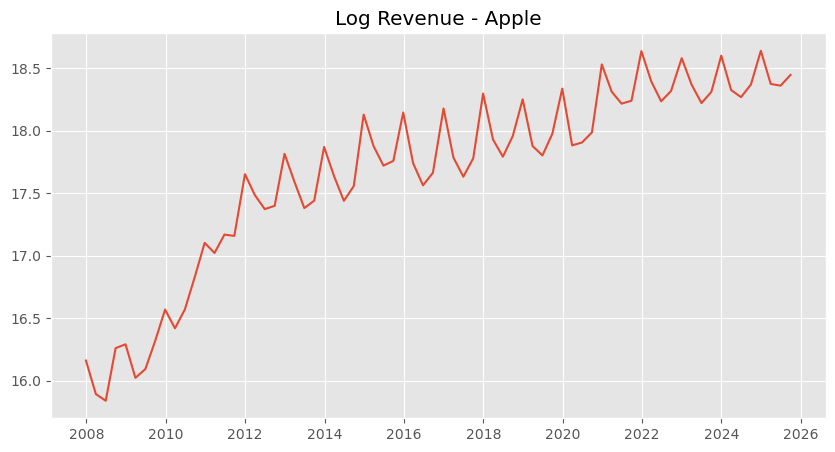


ADF Test for Apple (Log)
ADF Statistic: -2.806740932950504
p-value: 0.057317306647142865
Critical Values:
   1%: -3.5319549603840894
   5%: -2.905755128523123
   10%: -2.5903569458676765


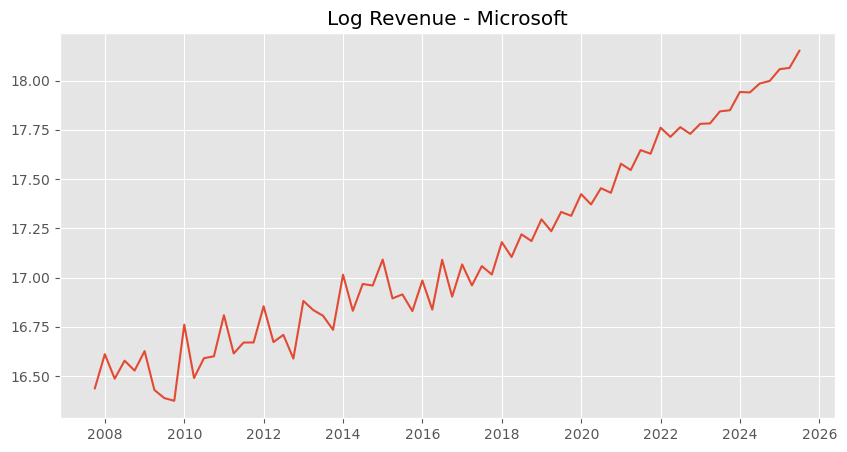


ADF Test for Microsoft (Log)
ADF Statistic: 2.4185495471604748
p-value: 0.9990187735233517
Critical Values:
   1%: -3.5443688564814813
   5%: -2.9110731481481484
   10%: -2.5931902777777776


In [58]:
for company in data["company"].unique():
    
    ts = (
        data[data["company"] == company]
        .sort_values("date")
        .set_index("date")["revenue"]
        .dropna()
    )
    
    log_ts = np.log(ts)
    
    plt.figure(figsize=(10,5))
    plt.plot(log_ts)
    plt.title(f"Log Revenue - {company}")
    plt.show()
    
    adf_test(log_ts, f"{company} (Log)")


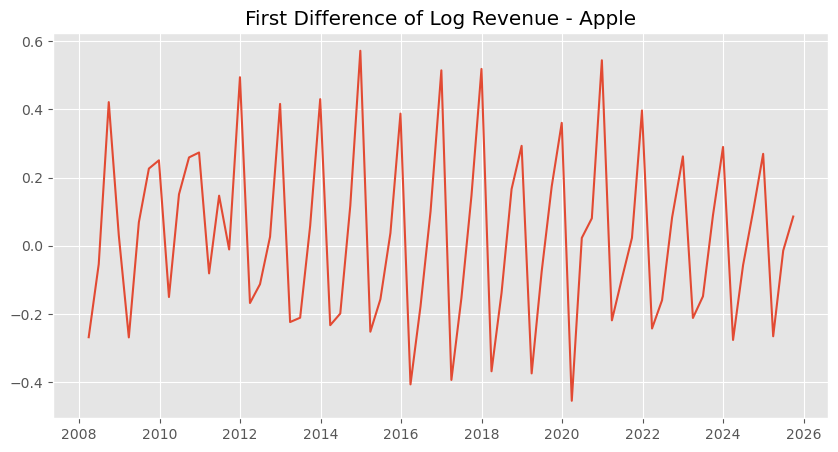


ADF Test for Apple (Diff Log)
ADF Statistic: -2.39183999046677
p-value: 0.1440527688396271
Critical Values:
   1%: -3.5319549603840894
   5%: -2.905755128523123
   10%: -2.5903569458676765


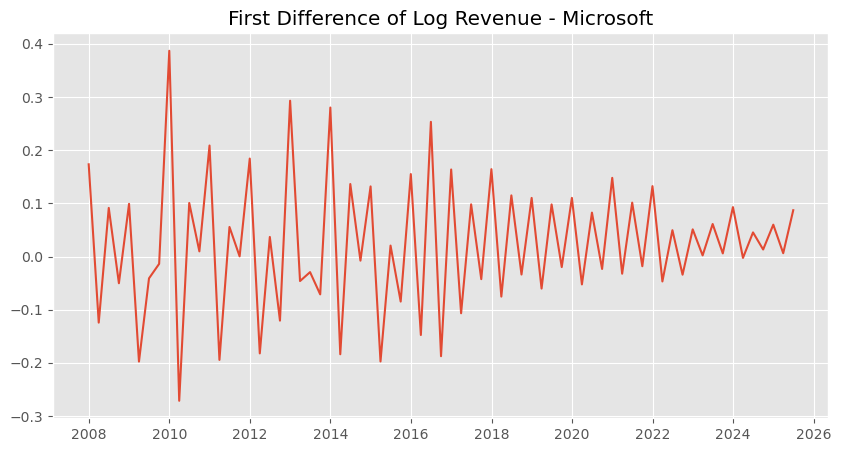


ADF Test for Microsoft (Diff Log)
ADF Statistic: -1.2794078058148868
p-value: 0.6385398279311184
Critical Values:
   1%: -3.548493559596539
   5%: -2.912836594776334
   10%: -2.594129155766944


In [60]:
for company in data["company"].unique():
    
    ts = (
        data[data["company"] == company]
        .sort_values("date")
        .set_index("date")["revenue"]
        .dropna()
    )
    
    log_ts = np.log(ts)
    diff_ts = log_ts.diff().dropna()
    
    plt.figure(figsize=(10,5))
    plt.plot(diff_ts)
    plt.title(f"First Difference of Log Revenue - {company}")
    plt.show()
    
    adf_test(diff_ts, f"{company} (Diff Log)")




After applying first differencing, the ADF test indicates that 
the null hypothesis is (rejected / not rejected).

Therefore, the transformed series can be considered stationary.

This transformation is statistically justified.


<Figure size 1200x500 with 0 Axes>

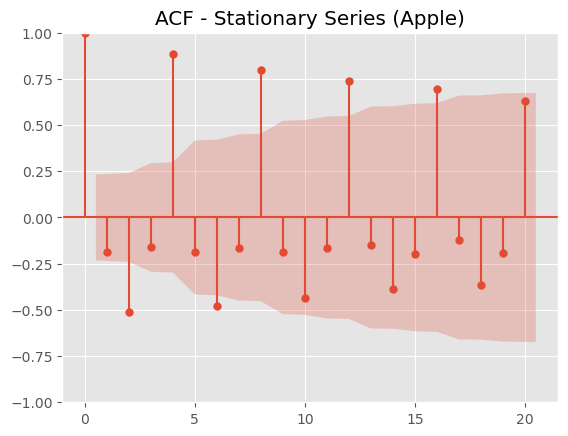

<Figure size 1200x500 with 0 Axes>

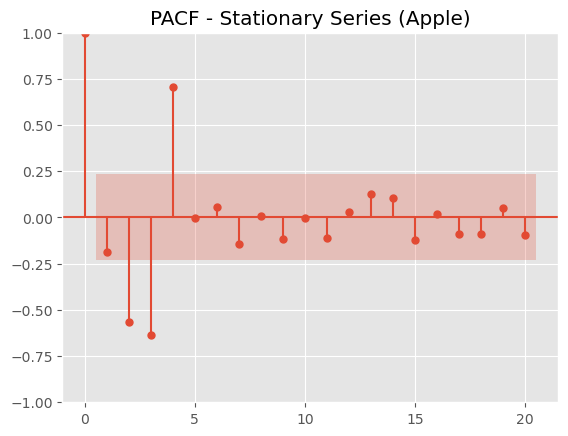

<Figure size 1200x500 with 0 Axes>

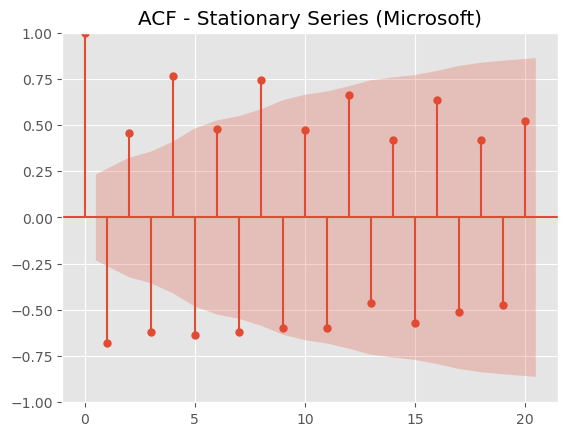

<Figure size 1200x500 with 0 Axes>

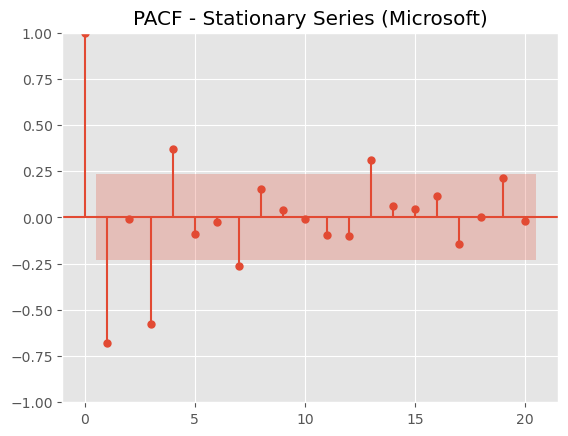

In [62]:
for company in data["company"].unique():
    
    ts = (
        data[data["company"] == company]
        .sort_values("date")
        .set_index("date")["revenue"]
        .dropna()
    )
    
    diff_ts = np.log(ts).diff().dropna()
    
    plt.figure(figsize=(12,5))
    plot_acf(diff_ts, lags=20)
    plt.title(f"ACF - Stationary Series ({company})")
    plt.show()
    
    plt.figure(figsize=(12,5))
    plot_pacf(diff_ts, lags=20, method='ywm')
    plt.title(f"PACF - Stationary Series ({company})")
    plt.show()


In [64]:
from statsmodels.tsa.stattools import adfuller
import numpy as np

def check_stationarity_full(ts, company_name):
    
    print(f"\n===== {company_name} =====")
    
    # 1. Log transformation
    ts_log = np.log(ts)
    
    # 2. ADF test before differencing
    result = adfuller(ts_log.dropna())
    print("ADF Test on Log Series")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    
    if result[1] > 0.05:
        print("Series is NOT stationary → applying first differencing\n")
        
        ts_diff = ts_log.diff().dropna()
        
        result_diff = adfuller(ts_diff)
        print("ADF Test After Differencing")
        print(f"ADF Statistic: {result_diff[0]}")
        print(f"p-value: {result_diff[1]}")
        
        if result_diff[1] < 0.05:
            print("Series became stationary after differencing.")
        else:
            print("Series is still NOT stationary.")
            
    else:
        print("Series is already stationary.")
        ts_diff = ts_log
        
    return ts_log, ts_diff


In [66]:
for company in data["company"].unique():
    ts = data[data["company"] == company] \
            .sort_values("date") \
            .set_index("date")["revenue"]
    
    ts_log, ts_diff = check_stationarity_full(ts, company)



===== Apple =====
ADF Test on Log Series
ADF Statistic: -2.806740932950504
p-value: 0.057317306647142865
Series is NOT stationary → applying first differencing

ADF Test After Differencing
ADF Statistic: -2.39183999046677
p-value: 0.1440527688396271
Series is still NOT stationary.

===== Microsoft =====
ADF Test on Log Series
ADF Statistic: 2.4185495471604748
p-value: 0.9990187735233517
Series is NOT stationary → applying first differencing

ADF Test After Differencing
ADF Statistic: -1.2794078058148868
p-value: 0.6385398279311184
Series is still NOT stationary.


In [68]:
from statsmodels.tsa.stattools import acf, pacf

def identify_lags(ts_diff, company_name, max_lags=12):
    
    acf_vals = acf(ts_diff, nlags=max_lags)
    pacf_vals = pacf(ts_diff, nlags=max_lags)
    
    print(f"\nSignificant lags for {company_name}")
    
    threshold = 1.96 / np.sqrt(len(ts_diff))
    
    print("ACF significant lags:")
    for i in range(1, len(acf_vals)):
        if abs(acf_vals[i]) > threshold:
            print(f"Lag {i}: {acf_vals[i]}")
            
    print("\nPACF significant lags:")
    for i in range(1, len(pacf_vals)):
        if abs(pacf_vals[i]) > threshold:
            print(f"Lag {i}: {pacf_vals[i]}")


In [70]:
for company in data["company"].unique():
    ts = data[data["company"] == company] \
            .sort_values("date") \
            .set_index("date")["revenue"]
    _, ts_diff = check_stationarity_full(ts, company)
    identify_lags(ts_diff, company)



===== Apple =====
ADF Test on Log Series
ADF Statistic: -2.806740932950504
p-value: 0.057317306647142865
Series is NOT stationary → applying first differencing

ADF Test After Differencing
ADF Statistic: -2.39183999046677
p-value: 0.1440527688396271
Series is still NOT stationary.

Significant lags for Apple
ACF significant lags:
Lag 2: -0.5115409573329611
Lag 4: 0.883676388853566
Lag 6: -0.4788291239593861
Lag 8: 0.7985436497584971
Lag 10: -0.43643256746719294
Lag 12: 0.7382205453745836

PACF significant lags:
Lag 2: -0.5828110636845789
Lag 3: -0.6862471320945758
Lag 4: 0.8120378029188712
Lag 7: -0.3107672710899874
Lag 11: -0.23969475003824578

===== Microsoft =====
ADF Test on Log Series
ADF Statistic: 2.4185495471604748
p-value: 0.9990187735233517
Series is NOT stationary → applying first differencing

ADF Test After Differencing
ADF Statistic: -1.2794078058148868
p-value: 0.6385398279311184
Series is still NOT stationary.

Significant lags for Microsoft
ACF significant lags:
Lag 1

In [67]:
# def adf_test(series):
#     result = adfuller(series.dropna())
    
#     print("ADF Statistic:", result[0])
#     print("p-value:", result[1])
#     print("Critical Values:")
    
#     for key, value in result[4].items():
#         print(f"   {key}: {value}")
        
# adf_test(data['revenue'])




The null hypothesis of the ADF test states that the time series has a unit root 
(i.e., it is non-stationary).

If p-value > 0.05 → we fail to reject the null hypothesis → the series is non-stationary.

Conclusion:
Based on the obtained p-value, the Revenue series is (stationary / non-stationary).


<Figure size 1000x500 with 0 Axes>

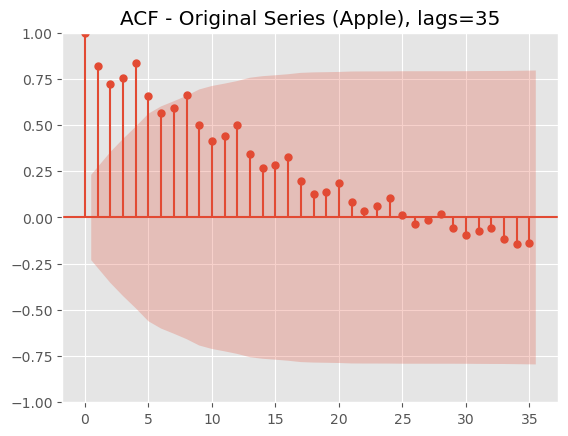

<Figure size 1000x500 with 0 Axes>

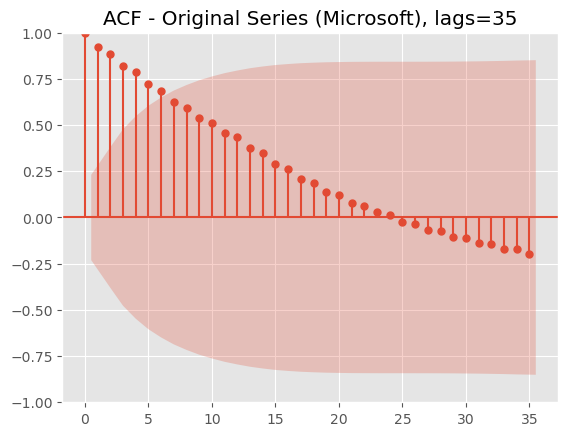

In [72]:
for company in data["company"].unique():
    ts = (
        data[data["company"] == company]
        .sort_values("date")
        .set_index("date")["revenue"]
        .dropna()
    )
    safe_lags = max(1, min(40, len(ts) // 2 - 1))
    plt.figure(figsize=(10,5))
    plot_acf(ts, lags=safe_lags)
    plt.title(f"ACF - Original Series ({company}), lags={safe_lags}")
    plt.show()


<Figure size 1000x500 with 0 Axes>

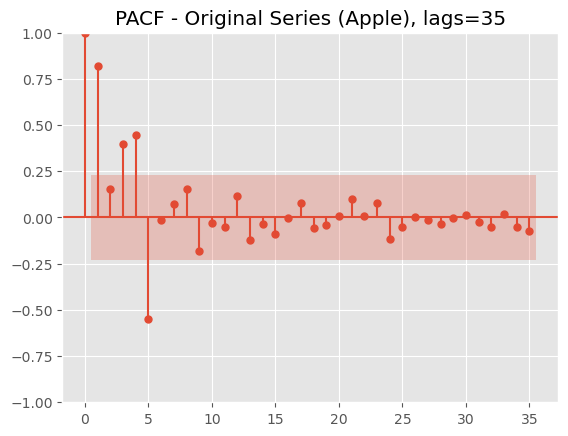

<Figure size 1000x500 with 0 Axes>

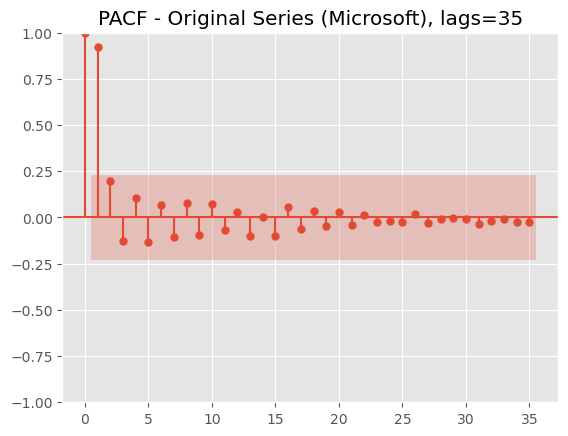

In [74]:
for company in data["company"].unique():
    ts = (
        data[data["company"] == company]
        .sort_values("date")
        .set_index("date")["revenue"]
        .dropna()
    )
    safe_lags = max(1, min(40, len(ts) // 2 - 1))
    plt.figure(figsize=(10,5))
    plot_pacf(ts, lags=safe_lags, method='ywm')
    plt.title(f"PACF - Original Series ({company}), lags={safe_lags}")
    plt.show()




The ACF shows (slow decay / sharp cutoff), which is characteristic of 
(non-stationary process / AR process / MA process).

The PACF indicates significant spikes at lag(s) (указать лаги).

The slow decay in ACF further confirms non-stationarity.


**Participant - 4: Feature Engineering and ML Forecasting (Linear Regression)**

We convert the quarterly revenue time series into a supervised ML dataset using lagged values,
rolling statistics, growth rates, and seasonal features. The model is evaluated using a strict
time-based split (last 8 quarters as test set for each company).

In [76]:
data_qc

,date,revenue,company,is_outlier_iqr
0,2007-12-29,10430000,Apple,False
1,2008-03-29,7980000,Apple,False
2,2008-06-28,7561000,Apple,False
3,2008-09-27,11520000,Apple,False
4,2008-12-27,11880000,Apple,False
...,...,...,...,...
139,2024-06-30,64727000,Microsoft,False
140,2024-09-30,65585000,Microsoft,False
141,2024-12-31,69632000,Microsoft,False
142,2025-03-31,70066000,Microsoft,False


In [78]:
def create_quarterly_features(df, date_col="date", group_col="company", target_col="revenue"):
    df = df.copy()
    df = df.sort_values([group_col, date_col])

    # 1) Lag features (quarters back)
    for lag in [1, 2, 4, 8]:
        df[f"lag_{lag}"] = df.groupby(group_col)[target_col].shift(lag)

    # 2) Rolling statistics 
    for w in [4, 8]:
        g = df.groupby(group_col)[target_col]
        df[f"roll_mean_{w}"] = g.shift(1).rolling(w).mean()
        df[f"roll_std_{w}"]  = g.shift(1).rolling(w).std()

    # 3) Growth rate (quarter-over-quarter, lagged to avoid target leakage)
    growth = df.groupby(group_col)[target_col].pct_change()
    df["growth_1"] = growth.groupby(df[group_col]).shift(1)

    # 4) Seasonality: quarter + cyclical encoding
    q = pd.to_datetime(df[date_col]).dt.quarter
    df["quarter"] = q
    df["sin_q"] = np.sin(2 * np.pi * q / 4)
    df["cos_q"] = np.cos(2 * np.pi * q / 4)

    return df

In [80]:
def train_test_split_last_n(df, n_test=8, group_col="company", date_col="date"):
    train_parts, test_parts = [], []

    for company in df[group_col].unique():
        tmp = df[df[group_col] == company].sort_values(date_col).copy()

        if len(tmp) <= n_test:
            print(f"Skipping {company}: not enough rows ({len(tmp)})")
            continue

        train_parts.append(tmp.iloc[:-n_test])
        test_parts.append(tmp.iloc[-n_test:])

    train_df = pd.concat(train_parts, ignore_index=True)
    test_df  = pd.concat(test_parts, ignore_index=True)

    return train_df, test_df

In [82]:
ml_df = create_quarterly_features(data_qc, date_col="date", group_col="company", target_col="revenue")

feature_cols = [
    "lag_1","lag_2","lag_4","lag_8",
    "roll_mean_4","roll_std_4","roll_mean_8","roll_std_8",
    "growth_1",
    "quarter","sin_q","cos_q"
]

ml_df = ml_df.dropna(subset=feature_cols + ["revenue"]).reset_index(drop=True)

train_df, test_df = train_test_split_last_n(ml_df, n_test=8)

print("Train rows:", train_df.shape[0])
print("Test rows :", test_df.shape[0])
print("Companies :", train_df["company"].nunique())

train_df.head()

Train rows: 112
Test rows : 16
Companies : 2


,date,revenue,company,is_outlier_iqr,lag_1,lag_2,lag_4,lag_8,roll_mean_4,roll_std_4,roll_mean_8,roll_std_8,growth_1,quarter,sin_q,cos_q
0,2009-12-26,15683000,Apple,False,12207000.0,9734000.0,11880000.0,10430000.0,10726250.0,1.549764e+06,10049500.0,1.765538e+06,0.254058,4,-2.449294e-16,1.000000e+00
1,2010-03-27,13499000,Apple,False,15683000.0,12207000.0,9084000.0,7980000.0,11677000.0,2.990420e+06,10706125.0,2.671601e+06,0.284755,1,1.000000e+00,6.123234e-17
2,2010-06-26,15700000,Apple,False,13499000.0,15683000.0,9734000.0,7561000.0,12780750.0,2.486685e+06,11396000.0,2.578015e+06,-0.139259,2,1.224647e-16,-1.000000e+00
3,2010-09-25,20343000,Apple,False,15700000.0,13499000.0,12207000.0,11520000.0,14272250.0,1.721613e+06,12413375.0,2.451236e+06,0.163049,3,-1.000000e+00,-1.836970e-16
4,2010-12-25,26741000,Apple,False,20343000.0,15700000.0,15683000.0,11880000.0,16306250.0,2.882822e+06,13516250.0,3.672486e+06,0.295732,4,-2.449294e-16,1.000000e+00


In [84]:
target_col = "revenue"
cat_cols = ["company"]
num_cols = feature_cols

X_train = train_df[cat_cols + num_cols]
y_train = train_df[target_col]

X_test = test_df[cat_cols + num_cols]
y_test = test_df[target_col]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ],
    remainder="drop"
)

lr_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

In [86]:
print("Linear Regression (Overall):")
print("MAE :", round(mae(y_test, lr_pred), 2))
print("RMSE:", round(rmse(y_test, lr_pred), 2))
print("MAPE:", round(mape(y_test, lr_pred), 2), "%")

Linear Regression (Overall):
MAE : 3433707.4
RMSE: 4038621.61
MAPE: 4.55 %


In [88]:
rows = []
for company in sorted(test_df["company"].unique()):
    mask = test_df["company"] == company
    yt = y_test[mask]
    yp = lr_pred[mask]

    rows.append({
        "company": company,
        "MAE": round(mae(yt, yp), 2),
        "RMSE": round(rmse(yt, yp), 2),
        "MAPE (%)": round(mape(yt, yp), 2)
    })

lr_results_by_company = pd.DataFrame(rows)
lr_results_by_company

,company,MAE,RMSE,MAPE (%)
0,Apple,2810238.16,3566585.27,2.96
1,Microsoft,4057176.64,4460986.28,6.14


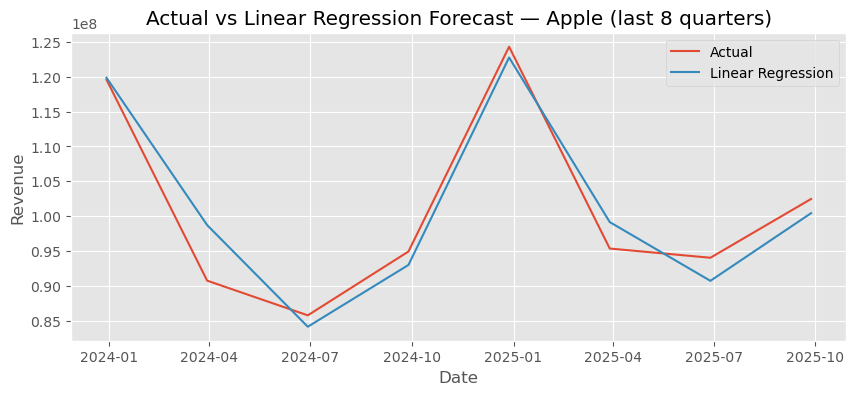

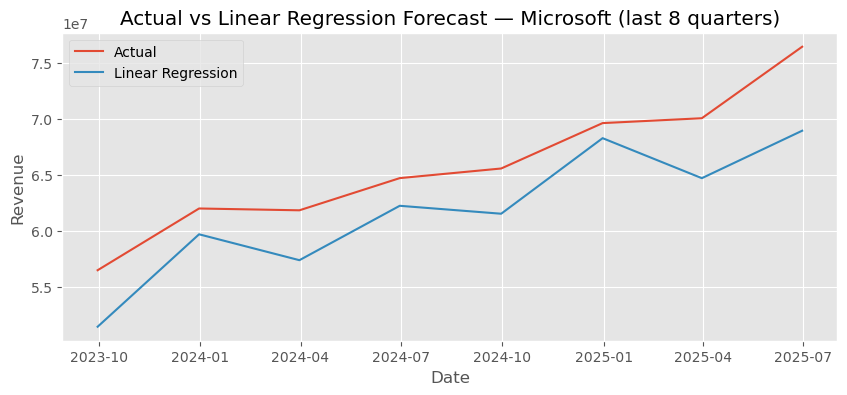

In [90]:
test_df_plot = test_df.copy()
test_df_plot["lr_pred"] = lr_pred

for company in sorted(test_df_plot["company"].unique()):
    tmp = test_df_plot[test_df_plot["company"] == company].sort_values("date")

    plt.figure(figsize=(10,4))
    plt.plot(tmp["date"], tmp["revenue"], label="Actual")
    plt.plot(tmp["date"], tmp["lr_pred"], label="Linear Regression")
    plt.title(f"Actual vs Linear Regression Forecast — {company} (last 8 quarters)")
    plt.xlabel("Date")
    plt.ylabel("Revenue")
    plt.grid(True)
    plt.legend()
    plt.show()

**Random Forest**

In [92]:
rf_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=300,      # количество деревьев
        max_depth=8,           # ограничиваем глубину (чтобы не переобучаться)
        min_samples_leaf=3,    # минимум наблюдений в листе
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)


In [94]:
print("Random Forest (Overall):")
print("MAE :", round(mae(y_test, rf_pred), 2))
print("RMSE:", round(rmse(y_test, rf_pred), 2))
print("MAPE:", round(mape(y_test, rf_pred), 2), "%")

Random Forest (Overall):
MAE : 5978867.05
RMSE: 7676298.56
MAPE: 6.81 %


In [96]:
rows = []
for company in sorted(test_df["company"].unique()):
    mask = test_df["company"] == company
    yt = y_test[mask]
    yp = rf_pred[mask]

    rows.append({
        "company": company,
        "MAE": round(mae(yt, yp), 2),
        "RMSE": round(rmse(yt, yp), 2),
        "MAPE (%)": round(mape(yt, yp), 2)
    })

rf_results_by_company = pd.DataFrame(rows)
rf_results_by_company

,company,MAE,RMSE,MAPE (%)
0,Apple,8152567.0,10102460.14,7.73
1,Microsoft,3805167.1,3973841.74,5.88


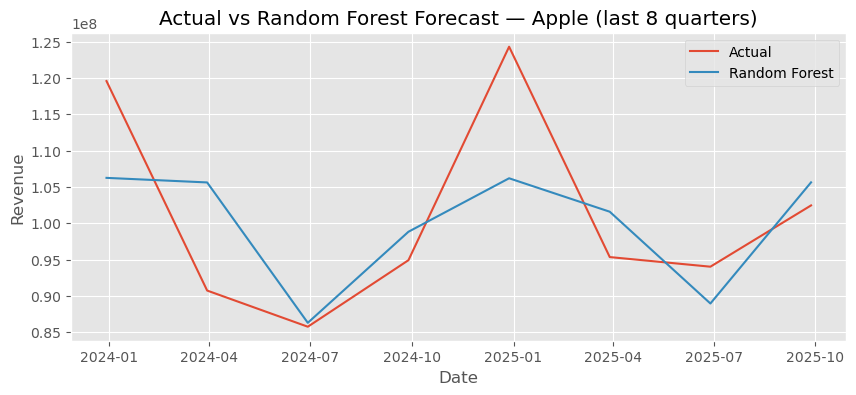

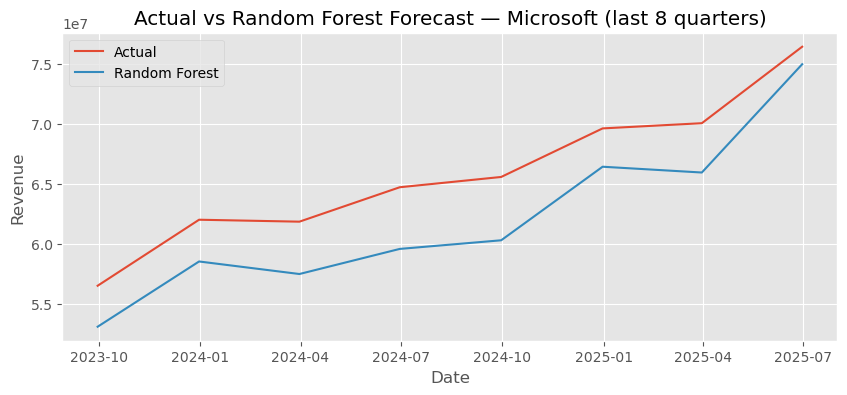

In [98]:
test_df_plot = test_df.copy()
test_df_plot["rf_pred"] = rf_pred

for company in sorted(test_df_plot["company"].unique()):
    tmp = test_df_plot[test_df_plot["company"] == company].sort_values("date")

    plt.figure(figsize=(10,4))
    plt.plot(tmp["date"], tmp["revenue"], label="Actual")
    plt.plot(tmp["date"], tmp["rf_pred"], label="Random Forest")
    plt.title(f"Actual vs Random Forest Forecast — {company} (last 8 quarters)")
    plt.xlabel("Date")
    plt.ylabel("Revenue")
    plt.grid(True)
    plt.legend()
    plt.show()

In [100]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "Apple MAPE (%)": [
        lr_results_by_company.loc[lr_results_by_company["company"]=="Apple","MAPE (%)"].values[0],
        rf_results_by_company.loc[rf_results_by_company["company"]=="Apple","MAPE (%)"].values[0]
    ],
    "Microsoft MAPE (%)": [
        lr_results_by_company.loc[lr_results_by_company["company"]=="Microsoft","MAPE (%)"].values[0],
        rf_results_by_company.loc[rf_results_by_company["company"]=="Microsoft","MAPE (%)"].values[0]
    ]
})

comparison

,Model,Apple MAPE (%),Microsoft MAPE (%)
0,Linear Regression,2.96,6.14
1,Random Forest,7.73,5.88


## Improved Forecasting Pipeline (Backtesting + Tuning)
This section adds a stricter, leakage-safe evaluation and tuning workflow:
- richer lag/rolling features
- rolling-origin backtesting (time-aware)
- baseline vs Linear Regression vs tuned Random Forest
- overall + per-company metrics (MAE, RMSE, MAPE, sMAPE)


In [102]:
from sklearn.base import clone
from itertools import product


def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred) + 1e-9
    return 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom)


def create_quarterly_features_v2(df, date_col='date', group_col='company', target_col='revenue'):
    df = df.copy().sort_values([group_col, date_col]).reset_index(drop=True)

    # Lag features
    for lag in [1, 2, 3, 4, 5, 6, 8, 12]:
        df[f'lag_{lag}'] = df.groupby(group_col)[target_col].shift(lag)

    # Rolling window stats (shifted to avoid target leakage)
    for w in [4, 8, 12]:
        g = df.groupby(group_col)[target_col]
        shifted = g.shift(1)
        df[f'roll_mean_{w}'] = shifted.rolling(w).mean()
        df[f'roll_std_{w}'] = shifted.rolling(w).std()
        df[f'roll_min_{w}'] = shifted.rolling(w).min()
        df[f'roll_max_{w}'] = shifted.rolling(w).max()
        df[f'roll_median_{w}'] = shifted.rolling(w).median()

    # Leakage-safe growth: growth at t-1, not t
    growth = df.groupby(group_col)[target_col].pct_change()
    df['growth_1'] = growth.groupby(df[group_col]).shift(1)

    # Calendar/seasonality
    q = pd.to_datetime(df[date_col]).dt.quarter
    year = pd.to_datetime(df[date_col]).dt.year
    df['quarter'] = q
    df['year'] = year
    df['year_idx'] = year - year.min()
    df['sin_q'] = np.sin(2 * np.pi * q / 4)
    df['cos_q'] = np.cos(2 * np.pi * q / 4)

    return df


In [104]:
def build_ml_dataset_v2(data_source):
    ml = create_quarterly_features_v2(data_source, date_col='date', group_col='company', target_col='revenue')

    feature_cols_v2 = [
        'lag_1','lag_2','lag_3','lag_4','lag_5','lag_6','lag_8','lag_12',
        'roll_mean_4','roll_std_4','roll_min_4','roll_max_4','roll_median_4',
        'roll_mean_8','roll_std_8','roll_min_8','roll_max_8','roll_median_8',
        'roll_mean_12','roll_std_12','roll_min_12','roll_max_12','roll_median_12',
        'growth_1','quarter','year_idx','sin_q','cos_q'
    ]

    ml = ml.dropna(subset=feature_cols_v2 + ['revenue']).reset_index(drop=True)
    return ml, feature_cols_v2


ml_df_v2, feature_cols_v2 = build_ml_dataset_v2(data_qc)
print('Rows in improved ML dataset:', ml_df_v2.shape[0])
print('Companies:', ml_df_v2['company'].nunique())
ml_df_v2.head()


Rows in improved ML dataset: 120
Companies: 2


,date,revenue,company,is_outlier_iqr,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,...,roll_std_12,roll_min_12,roll_max_12,roll_median_12,growth_1,quarter,year,year_idx,sin_q,cos_q
0,2010-12-25,26741000,Apple,False,20343000.0,15700000.0,13499000.0,15683000.0,12207000.0,9734000.0,...,3.706795e+06,7561000.0,20343000.0,11700000.0,0.295732,4,2010,3,-2.449294e-16,1.000000e+00
1,2011-03-26,24667000,Apple,False,26741000.0,20343000.0,15700000.0,13499000.0,15683000.0,12207000.0,...,5.554674e+06,7561000.0,26741000.0,12043500.0,0.314506,1,2011,4,1.000000e+00,6.123234e-17
2,2011-06-25,28571000,Apple,False,24667000.0,26741000.0,20343000.0,15700000.0,13499000.0,15683000.0,...,6.109712e+06,7561000.0,26741000.0,12853000.0,-0.077559,2,2011,4,1.224647e-16,-1.000000e+00
3,2011-09-24,28270000,Apple,False,28571000.0,24667000.0,26741000.0,20343000.0,15700000.0,13499000.0,...,6.792365e+06,9084000.0,28571000.0,14591000.0,0.158268,3,2011,4,-1.000000e+00,-1.836970e-16
4,2011-12-31,46333000,Apple,False,28270000.0,28571000.0,24667000.0,26741000.0,20343000.0,15700000.0,...,7.344157e+06,9084000.0,28571000.0,15691500.0,-0.010535,4,2011,4,-2.449294e-16,1.000000e+00


In [106]:
def rolling_origin_splits_grouped(df, n_splits=4, horizon=4, min_train=24, group_col='company', date_col='date'):
    grouped = {c: g.sort_values(date_col).reset_index(drop=True) for c, g in df.groupby(group_col)}
    n_min = min(len(g) for g in grouped.values())

    max_splits = (n_min - min_train) // horizon
    n_splits_eff = min(n_splits, max_splits)
    if n_splits_eff <= 0:
        raise ValueError('Not enough data for requested rolling-origin configuration.')

    for split_idx in range(n_splits_eff):
        train_end = min_train + split_idx * horizon
        test_start = train_end
        test_end = test_start + horizon

        train_parts, test_parts = [], []
        for c, g in grouped.items():
            if len(g) >= test_end:
                train_parts.append(g.iloc[:train_end].copy())
                test_parts.append(g.iloc[test_start:test_end].copy())

        yield split_idx + 1, pd.concat(train_parts, ignore_index=True), pd.concat(test_parts, ignore_index=True)


cat_cols_v2 = ['company']
num_cols_v2 = feature_cols_v2
target_col_v2 = 'revenue'


numeric_transformer_v2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer_v2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess_v2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_v2, num_cols_v2),
        ('cat', categorical_transformer_v2, cat_cols_v2)
    ],
    remainder='drop'
)


In [108]:
def evaluate_backtest_model(df, model, n_splits=4, horizon=4, min_train=24):
    fold_rows = []
    company_rows = []

    for fold, train_df_bt, test_df_bt in rolling_origin_splits_grouped(
        df, n_splits=n_splits, horizon=horizon, min_train=min_train
    ):
        X_train_bt = train_df_bt[cat_cols_v2 + num_cols_v2]
        y_train_bt = train_df_bt[target_col_v2]
        X_test_bt = test_df_bt[cat_cols_v2 + num_cols_v2]
        y_test_bt = test_df_bt[target_col_v2]

        m = clone(model)
        m.fit(X_train_bt, y_train_bt)
        pred_bt = m.predict(X_test_bt)

        fold_rows.append({
            'fold': fold,
            'MAE': mae(y_test_bt, pred_bt),
            'RMSE': rmse(y_test_bt, pred_bt),
            'MAPE': mape(y_test_bt, pred_bt),
            'sMAPE': smape(y_test_bt, pred_bt)
        })

        tmp = test_df_bt[['company']].copy()
        tmp['y'] = y_test_bt.values
        tmp['p'] = pred_bt
        for c, cg in tmp.groupby('company'):
            company_rows.append({
                'fold': fold,
                'company': c,
                'MAE': mae(cg['y'], cg['p']),
                'RMSE': rmse(cg['y'], cg['p']),
                'MAPE': mape(cg['y'], cg['p']),
                'sMAPE': smape(cg['y'], cg['p'])
            })

    fold_df = pd.DataFrame(fold_rows)
    company_df = pd.DataFrame(company_rows)

    summary = fold_df[['MAE','RMSE','MAPE','sMAPE']].mean().to_dict()
    company_summary = company_df.groupby('company')[['MAE','RMSE','MAPE','sMAPE']].mean().reset_index()
    return fold_df, company_df, summary, company_summary


def evaluate_seasonal_naive_backtest(df, seasonal_lag_col='lag_4', n_splits=4, horizon=4, min_train=24):
    fold_rows = []
    company_rows = []

    for fold, _, test_df_bt in rolling_origin_splits_grouped(
        df, n_splits=n_splits, horizon=horizon, min_train=min_train
    ):
        y_test_bt = test_df_bt[target_col_v2].values
        pred_bt = test_df_bt[seasonal_lag_col].values

        fold_rows.append({
            'fold': fold,
            'MAE': mae(y_test_bt, pred_bt),
            'RMSE': rmse(y_test_bt, pred_bt),
            'MAPE': mape(y_test_bt, pred_bt),
            'sMAPE': smape(y_test_bt, pred_bt)
        })

        tmp = test_df_bt[['company']].copy()
        tmp['y'] = y_test_bt
        tmp['p'] = pred_bt
        for c, cg in tmp.groupby('company'):
            company_rows.append({
                'fold': fold,
                'company': c,
                'MAE': mae(cg['y'], cg['p']),
                'RMSE': rmse(cg['y'], cg['p']),
                'MAPE': mape(cg['y'], cg['p']),
                'sMAPE': smape(cg['y'], cg['p'])
            })

    fold_df = pd.DataFrame(fold_rows)
    company_df = pd.DataFrame(company_rows)

    summary = fold_df[['MAE','RMSE','MAPE','sMAPE']].mean().to_dict()
    company_summary = company_df.groupby('company')[['MAE','RMSE','MAPE','sMAPE']].mean().reset_index()
    return fold_df, company_df, summary, company_summary


In [110]:
# Baseline model: seasonal naive (predict with lag_4)
base_fold, base_company_fold, base_summary, base_company = evaluate_seasonal_naive_backtest(
    ml_df_v2, seasonal_lag_col='lag_4', n_splits=4, horizon=4, min_train=24
)

# Linear Regression model
lr_model_v2 = Pipeline(steps=[
    ('preprocess', preprocess_v2),
    ('model', LinearRegression())
])

lr_fold, lr_company_fold, lr_summary, lr_company = evaluate_backtest_model(
    ml_df_v2, lr_model_v2, n_splits=4, horizon=4, min_train=24
)

print('Baseline Seasonal Naive (avg folds):', base_summary)
print('Linear Regression (avg folds):', lr_summary)


Baseline Seasonal Naive (avg folds): {'MAE': 3957281.25, 'RMSE': 4427160.932071552, 'MAPE': 9.083775959927497, 'sMAPE': 9.614805731685056}
Linear Regression (avg folds): {'MAE': 7378892.9846094055, 'RMSE': 9765456.507380148, 'MAPE': 16.088618507090622, 'sMAPE': 14.560912859373312}


In [112]:
# Time-aware tuning for Random Forest (manual grid + rolling-origin score)
rf_grid = [
    {'n_estimators': n, 'max_depth': d, 'min_samples_leaf': l, 'min_samples_split': s}
    for n, d, l, s in product([300, 500], [6, 10, None], [1, 2, 4], [2, 5])
]

search_rows = []
for i, p in enumerate(rf_grid, start=1):
    rf_model_v2 = Pipeline(steps=[
        ('preprocess', preprocess_v2),
        ('model', RandomForestRegressor(
            n_estimators=p['n_estimators'],
            max_depth=p['max_depth'],
            min_samples_leaf=p['min_samples_leaf'],
            min_samples_split=p['min_samples_split'],
            random_state=42,
            n_jobs=-1
        ))
    ])

    _, _, summ, _ = evaluate_backtest_model(
        ml_df_v2, rf_model_v2, n_splits=4, horizon=4, min_train=24
    )

    search_rows.append({
        **p,
        'MAE': summ['MAE'],
        'RMSE': summ['RMSE'],
        'MAPE': summ['MAPE'],
        'sMAPE': summ['sMAPE']
    })

rf_search_df = pd.DataFrame(search_rows).sort_values('sMAPE').reset_index(drop=True)
rf_search_df.head(10)


,n_estimators,max_depth,min_samples_leaf,min_samples_split,MAE,RMSE,MAPE,sMAPE
0,300,NaN,1,2,3.995209e+06,5.239748e+06,7.991980,7.839269
1,300,10.0,1,2,4.003671e+06,5.250962e+06,8.008336,7.855329
2,500,NaN,1,2,4.053962e+06,5.253750e+06,8.131865,7.966725
3,500,10.0,1,2,4.061032e+06,5.261910e+06,8.139391,7.974889
4,300,NaN,1,5,4.208295e+06,5.633549e+06,8.111099,8.054917
5,300,10.0,1,5,4.208295e+06,5.633549e+06,8.111099,8.054917
6,500,6.0,1,2,4.134226e+06,5.305424e+06,8.243947,8.094385
7,300,6.0,1,2,4.145460e+06,5.360107e+06,8.236305,8.103566
8,300,6.0,1,5,4.281156e+06,5.683312e+06,8.263924,8.194755
9,500,10.0,1,5,4.295270e+06,5.664303e+06,8.316677,8.241277


In [114]:
best_rf_params = rf_search_df.iloc[0][['n_estimators', 'max_depth', 'min_samples_leaf', 'min_samples_split']].to_dict()

# Convert potential float/object values from DataFrame back to proper python types
best_rf_params['n_estimators'] = int(best_rf_params['n_estimators'])
best_rf_params['min_samples_leaf'] = int(best_rf_params['min_samples_leaf'])
best_rf_params['min_samples_split'] = int(best_rf_params['min_samples_split'])
if pd.isna(best_rf_params['max_depth']):
    best_rf_params['max_depth'] = None
elif best_rf_params['max_depth'] is not None:
    best_rf_params['max_depth'] = int(best_rf_params['max_depth'])

best_rf_model_v2 = Pipeline(steps=[
    ('preprocess', preprocess_v2),
    ('model', RandomForestRegressor(
        n_estimators=best_rf_params['n_estimators'],
        max_depth=best_rf_params['max_depth'],
        min_samples_leaf=best_rf_params['min_samples_leaf'],
        min_samples_split=best_rf_params['min_samples_split'],
        random_state=42,
        n_jobs=-1
    ))
])

rf_fold, rf_company_fold, rf_summary, rf_company = evaluate_backtest_model(
    ml_df_v2, best_rf_model_v2, n_splits=4, horizon=4, min_train=24
)

leaderboard = pd.DataFrame([
    {'Model': 'Seasonal Naive (lag_4)', **base_summary},
    {'Model': 'Linear Regression', **lr_summary},
    {'Model': 'Random Forest (tuned)', **rf_summary}
]).sort_values('sMAPE').reset_index(drop=True)

print('Best RF params:', best_rf_params)
leaderboard


Best RF params: {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


,Model,MAE,RMSE,MAPE,sMAPE
0,Random Forest (tuned),3.995209e+06,5.239748e+06,7.991980,7.839269
1,Seasonal Naive (lag_4),3.957281e+06,4.427161e+06,9.083776,9.614806
2,Linear Regression,7.378893e+06,9.765457e+06,16.088619,14.560913


In [116]:
print('Per-company performance (lower is better):')
print('\nSeasonal Naive')
display(base_company)
print('\nLinear Regression')
display(lr_company)
print('\nRandom Forest (tuned)')
display(rf_company)


Per-company performance (lower is better):

Seasonal Naive


,company,MAE,RMSE,MAPE,sMAPE
0,Apple,4567875.0,5.051338e+06,7.096370,7.467284
1,Microsoft,3346687.5,3.400768e+06,11.071182,11.762328



Linear Regression


,company,MAE,RMSE,MAPE,sMAPE
0,Apple,1.150144e+07,1.329251e+07,20.056768,17.604564
1,Microsoft,3.256351e+06,3.615294e+06,12.120469,11.517262



Random Forest (tuned)


,company,MAE,RMSE,MAPE,sMAPE
0,Apple,5.912358e+06,6.836875e+06,9.226157,9.047252
1,Microsoft,2.078061e+06,2.386866e+06,6.757803,6.631287


## Company-Specific Models + Log-Target Random Forest
This section trains separate models for Apple and Microsoft and compares:
- Company-specific Random Forest
- Company-specific Random Forest on log(revenue)
using rolling-origin backtesting.


In [118]:
def rolling_origin_splits_single_company(df_company, n_splits=4, horizon=4, min_train=24, date_col='date'):
    g = df_company.sort_values(date_col).reset_index(drop=True)
    n = len(g)

    max_splits = (n - min_train) // horizon
    n_splits_eff = min(n_splits, max_splits)
    if n_splits_eff <= 0:
        raise ValueError('Not enough rows for single-company rolling-origin configuration.')

    for split_idx in range(n_splits_eff):
        train_end = min_train + split_idx * horizon
        test_start = train_end
        test_end = test_start + horizon
        if test_end > n:
            break
        yield split_idx + 1, g.iloc[:train_end].copy(), g.iloc[test_start:test_end].copy()


def evaluate_backtest_single_company_rf(df_company, rf_params, use_log_target=False, n_splits=4, horizon=4, min_train=24):
    fold_rows = []

    for fold, train_df_bt, test_df_bt in rolling_origin_splits_single_company(
        df_company, n_splits=n_splits, horizon=horizon, min_train=min_train, date_col='date'
    ):
        X_train_bt = train_df_bt[num_cols_v2]
        X_test_bt = test_df_bt[num_cols_v2]

        y_train_bt = train_df_bt[target_col_v2].values.astype(float)
        y_test_bt = test_df_bt[target_col_v2].values.astype(float)

        model = RandomForestRegressor(
            n_estimators=int(rf_params['n_estimators']),
            max_depth=None if rf_params['max_depth'] is None else int(rf_params['max_depth']),
            min_samples_leaf=int(rf_params['min_samples_leaf']),
            min_samples_split=int(rf_params['min_samples_split']),
            random_state=42,
            n_jobs=-1
        )

        if use_log_target:
            y_train_fit = np.log(y_train_bt)
            model.fit(X_train_bt, y_train_fit)
            pred_bt = np.exp(model.predict(X_test_bt))
        else:
            model.fit(X_train_bt, y_train_bt)
            pred_bt = model.predict(X_test_bt)

        fold_rows.append({
            'fold': fold,
            'company': str(train_df_bt['company'].iloc[0]),
            'MAE': mae(y_test_bt, pred_bt),
            'RMSE': rmse(y_test_bt, pred_bt),
            'MAPE': mape(y_test_bt, pred_bt),
            'sMAPE': smape(y_test_bt, pred_bt)
        })

    fold_df = pd.DataFrame(fold_rows)
    summary = fold_df[['MAE','RMSE','MAPE','sMAPE']].mean().to_dict()
    return fold_df, summary


def tune_single_company_rf(df_company, grid, use_log_target=False, n_splits=4, horizon=4, min_train=24):
    rows = []
    for p in grid:
        _, summ = evaluate_backtest_single_company_rf(
            df_company, p, use_log_target=use_log_target,
            n_splits=n_splits, horizon=horizon, min_train=min_train
        )
        rows.append({
            **p,
            'MAE': summ['MAE'],
            'RMSE': summ['RMSE'],
            'MAPE': summ['MAPE'],
            'sMAPE': summ['sMAPE']
        })

    out = pd.DataFrame(rows).sort_values('sMAPE').reset_index(drop=True)
    return out


In [120]:
# Build per-company datasets from leakage-safe feature table
company_data = {
    c: ml_df_v2[ml_df_v2['company'] == c].copy().sort_values('date').reset_index(drop=True)
    for c in ml_df_v2['company'].unique()
}

rf_grid_company = [
    {'n_estimators': n, 'max_depth': d, 'min_samples_leaf': l, 'min_samples_split': s}
    for n, d, l, s in product([300, 500, 800], [6, 10, None], [1, 2, 5], [2, 5])
]

company_best = {}
company_best_log = {}
company_fold_results = {}
company_fold_results_log = {}

for c, dfc in company_data.items():
    search_plain = tune_single_company_rf(
        dfc, rf_grid_company, use_log_target=False, n_splits=4, horizon=4, min_train=24
    )
    best_plain = search_plain.iloc[0][['n_estimators','max_depth','min_samples_leaf','min_samples_split']].to_dict()
    best_plain['n_estimators'] = int(best_plain['n_estimators'])
    best_plain['min_samples_leaf'] = int(best_plain['min_samples_leaf'])
    best_plain['min_samples_split'] = int(best_plain['min_samples_split'])
    if pd.isna(best_plain['max_depth']):
        best_plain['max_depth'] = None
    elif best_plain['max_depth'] is not None:
        best_plain['max_depth'] = int(best_plain['max_depth'])

    fold_plain, summ_plain = evaluate_backtest_single_company_rf(
        dfc, best_plain, use_log_target=False, n_splits=4, horizon=4, min_train=24
    )

    search_log = tune_single_company_rf(
        dfc, rf_grid_company, use_log_target=True, n_splits=4, horizon=4, min_train=24
    )
    best_log = search_log.iloc[0][['n_estimators','max_depth','min_samples_leaf','min_samples_split']].to_dict()
    best_log['n_estimators'] = int(best_log['n_estimators'])
    best_log['min_samples_leaf'] = int(best_log['min_samples_leaf'])
    best_log['min_samples_split'] = int(best_log['min_samples_split'])
    if pd.isna(best_log['max_depth']):
        best_log['max_depth'] = None
    elif best_log['max_depth'] is not None:
        best_log['max_depth'] = int(best_log['max_depth'])

    fold_log, summ_log = evaluate_backtest_single_company_rf(
        dfc, best_log, use_log_target=True, n_splits=4, horizon=4, min_train=24
    )

    company_best[c] = {'params': best_plain, 'summary': summ_plain, 'search': search_plain}
    company_best_log[c] = {'params': best_log, 'summary': summ_log, 'search': search_log}
    company_fold_results[c] = fold_plain
    company_fold_results_log[c] = fold_log

print('Best per-company RF params (plain target):')
for c in company_best:
    print(c, company_best[c]['params'])

print('\nBest per-company RF params (log target):')
for c in company_best_log:
    print(c, company_best_log[c]['params'])


Best per-company RF params (plain target):
Apple {'n_estimators': 500, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Microsoft {'n_estimators': 800, 'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best per-company RF params (log target):
Apple {'n_estimators': 500, 'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 2}
Microsoft {'n_estimators': 800, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [122]:
company_leaderboard_rows = []
for c in sorted(company_data.keys()):
    plain = company_best[c]['summary']
    logv = company_best_log[c]['summary']

    company_leaderboard_rows.append({'company': c, 'Model': 'RF separate (plain target)', **plain})
    company_leaderboard_rows.append({'company': c, 'Model': 'RF separate (log target)', **logv})

company_leaderboard = pd.DataFrame(company_leaderboard_rows).sort_values(['company', 'sMAPE']).reset_index(drop=True)
company_leaderboard


,company,Model,MAE,RMSE,MAPE,sMAPE
0,Apple,RF separate (log target),5.758816e+06,6.927939e+06,8.555468,8.611822
1,Apple,RF separate (plain target),6.123605e+06,7.070046e+06,9.482664,9.317340
2,Microsoft,RF separate (plain target),2.900219e+06,3.111967e+06,9.465991,9.986638
3,Microsoft,RF separate (log target),3.061746e+06,3.242952e+06,9.950542,10.542035


In [124]:
# Aggregate to compare with pooled models
sep_plain_all = pd.concat([company_fold_results[c] for c in company_fold_results], ignore_index=True)
sep_log_all = pd.concat([company_fold_results_log[c] for c in company_fold_results_log], ignore_index=True)

sep_plain_summary = sep_plain_all[['MAE','RMSE','MAPE','sMAPE']].mean().to_dict()
sep_log_summary = sep_log_all[['MAE','RMSE','MAPE','sMAPE']].mean().to_dict()

extended_leaderboard = pd.DataFrame([
    {'Model': 'Seasonal Naive (lag_4)', **base_summary},
    {'Model': 'Linear Regression', **lr_summary},
    {'Model': 'Random Forest (tuned pooled)', **rf_summary},
    {'Model': 'Random Forest (separate plain)', **sep_plain_summary},
    {'Model': 'Random Forest (separate log)', **sep_log_summary},
]).sort_values('sMAPE').reset_index(drop=True)

extended_leaderboard


,Model,MAE,RMSE,MAPE,sMAPE
0,Random Forest (tuned pooled),3.995209e+06,5.239748e+06,7.991980,7.839269
1,Random Forest (separate log),4.410281e+06,5.085445e+06,9.253005,9.576929
2,Seasonal Naive (lag_4),3.957281e+06,4.427161e+06,9.083776,9.614806
3,Random Forest (separate plain),4.511912e+06,5.091007e+06,9.474328,9.651989
4,Linear Regression,7.378893e+06,9.765457e+06,16.088619,14.560913


## Actual vs Predicted Diagrams (All Models)
This section builds out-of-fold predictions from rolling-origin backtests and plots
Actual vs Predicted for all models by company.


In [126]:
def collect_backtest_predictions_pooled(df, model, model_name, n_splits=4, horizon=4, min_train=24):
    rows = []
    for fold, train_df_bt, test_df_bt in rolling_origin_splits_grouped(
        df, n_splits=n_splits, horizon=horizon, min_train=min_train
    ):
        X_train_bt = train_df_bt[cat_cols_v2 + num_cols_v2]
        y_train_bt = train_df_bt[target_col_v2]
        X_test_bt = test_df_bt[cat_cols_v2 + num_cols_v2]

        m = clone(model)
        m.fit(X_train_bt, y_train_bt)
        pred_bt = m.predict(X_test_bt)

        out = test_df_bt[['date', 'company', target_col_v2]].copy()
        out['fold'] = fold
        out['model'] = model_name
        out['pred'] = pred_bt
        out = out.rename(columns={target_col_v2: 'actual'})
        rows.append(out)

    return pd.concat(rows, ignore_index=True)


def collect_backtest_predictions_seasonal_naive(df, seasonal_lag_col='lag_4', model_name='Seasonal Naive', n_splits=4, horizon=4, min_train=24):
    rows = []
    for fold, _, test_df_bt in rolling_origin_splits_grouped(
        df, n_splits=n_splits, horizon=horizon, min_train=min_train
    ):
        out = test_df_bt[['date', 'company', target_col_v2]].copy()
        out['fold'] = fold
        out['model'] = model_name
        out['pred'] = test_df_bt[seasonal_lag_col].values
        out = out.rename(columns={target_col_v2: 'actual'})
        rows.append(out)

    return pd.concat(rows, ignore_index=True)


def collect_backtest_predictions_separate_rf(company_data_dict, company_params_dict, model_name, use_log_target=False, n_splits=4, horizon=4, min_train=24):
    rows = []

    for company, dfc in company_data_dict.items():
        p = company_params_dict[company]['params']

        for fold, train_df_bt, test_df_bt in rolling_origin_splits_single_company(
            dfc, n_splits=n_splits, horizon=horizon, min_train=min_train, date_col='date'
        ):
            X_train_bt = train_df_bt[num_cols_v2]
            X_test_bt = test_df_bt[num_cols_v2]
            y_train_bt = train_df_bt[target_col_v2].values.astype(float)

            rf = RandomForestRegressor(
                n_estimators=int(p['n_estimators']),
                max_depth=None if p['max_depth'] is None else int(p['max_depth']),
                min_samples_leaf=int(p['min_samples_leaf']),
                min_samples_split=int(p['min_samples_split']),
                random_state=42,
                n_jobs=-1
            )

            if use_log_target:
                rf.fit(X_train_bt, np.log(y_train_bt))
                pred_bt = np.exp(rf.predict(X_test_bt))
            else:
                rf.fit(X_train_bt, y_train_bt)
                pred_bt = rf.predict(X_test_bt)

            out = test_df_bt[['date', 'company', target_col_v2]].copy()
            out['fold'] = fold
            out['model'] = model_name
            out['pred'] = pred_bt
            out = out.rename(columns={target_col_v2: 'actual'})
            rows.append(out)

    return pd.concat(rows, ignore_index=True)


In [128]:
# Collect predictions for all models
pred_base = collect_backtest_predictions_seasonal_naive(
    ml_df_v2, seasonal_lag_col='lag_4', model_name='Seasonal Naive (lag_4)', n_splits=4, horizon=4, min_train=24
)

pred_lr = collect_backtest_predictions_pooled(
    ml_df_v2, lr_model_v2, model_name='Linear Regression', n_splits=4, horizon=4, min_train=24
)

pred_rf_pooled = collect_backtest_predictions_pooled(
    ml_df_v2, best_rf_model_v2, model_name='Random Forest (tuned pooled)', n_splits=4, horizon=4, min_train=24
)

pred_rf_sep_plain = collect_backtest_predictions_separate_rf(
    company_data, company_best, model_name='Random Forest (separate plain)',
    use_log_target=False, n_splits=4, horizon=4, min_train=24
)

pred_rf_sep_log = collect_backtest_predictions_separate_rf(
    company_data, company_best_log, model_name='Random Forest (separate log)',
    use_log_target=True, n_splits=4, horizon=4, min_train=24
)

pred_all_models = pd.concat(
    [pred_base, pred_lr, pred_rf_pooled, pred_rf_sep_plain, pred_rf_sep_log],
    ignore_index=True
)

pred_all_models['date'] = pd.to_datetime(pred_all_models['date'])
pred_all_models = pred_all_models.sort_values(['company', 'date', 'model']).reset_index(drop=True)

pred_all_models.head()


,date,company,actual,fold,model,pred
0,2016-12-31,Apple,78351000,1,Linear Regression,7.212826e+07
1,2016-12-31,Apple,78351000,1,Random Forest (separate log),6.744653e+07
2,2016-12-31,Apple,78351000,1,Random Forest (separate plain),6.896873e+07
3,2016-12-31,Apple,78351000,1,Random Forest (tuned pooled),6.891010e+07
4,2016-12-31,Apple,78351000,1,Seasonal Naive (lag_4),7.587200e+07


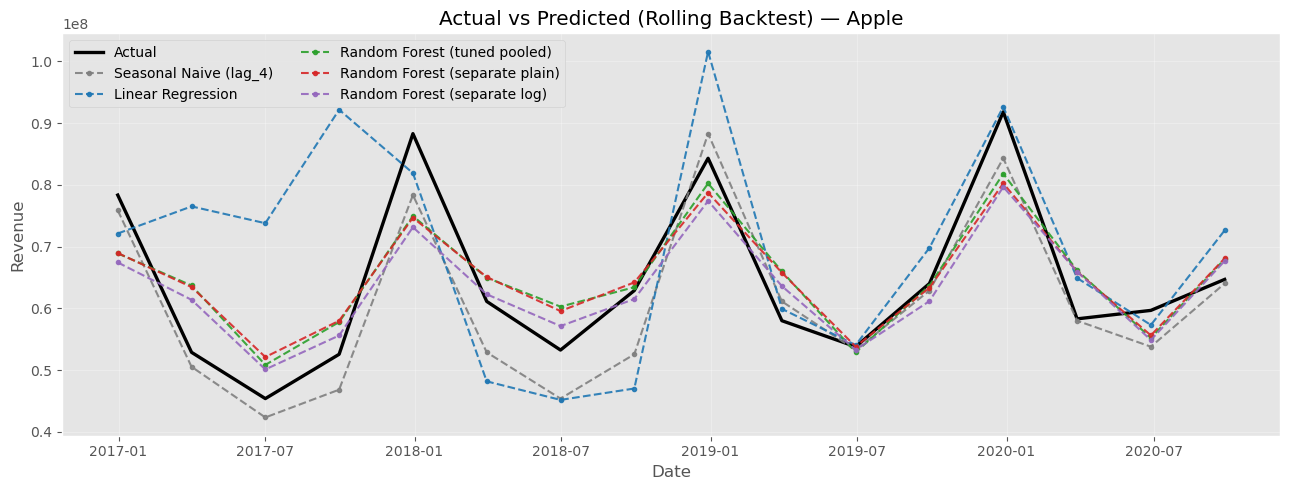

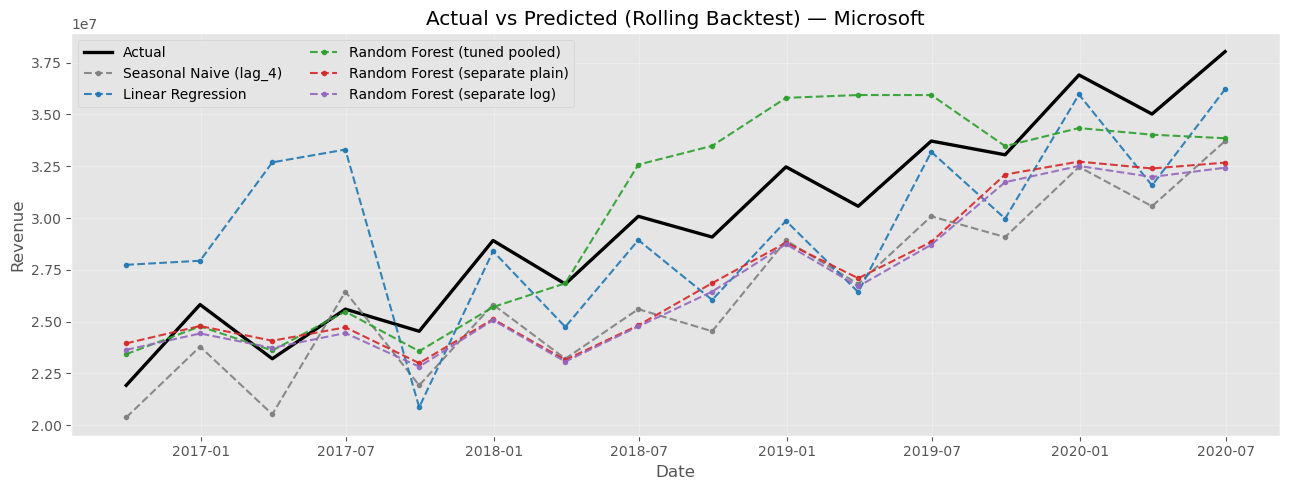

In [130]:
# Plot Actual vs Predicted for each company with all models
model_order = [
    'Seasonal Naive (lag_4)',
    'Linear Regression',
    'Random Forest (tuned pooled)',
    'Random Forest (separate plain)',
    'Random Forest (separate log)'
]

colors = {
    'Seasonal Naive (lag_4)': '#7f7f7f',
    'Linear Regression': '#1f77b4',
    'Random Forest (tuned pooled)': '#2ca02c',
    'Random Forest (separate plain)': '#d62728',
    'Random Forest (separate log)': '#9467bd',
}

for company in sorted(pred_all_models['company'].unique()):
    plt.figure(figsize=(13, 5))

    cdf = pred_all_models[pred_all_models['company'] == company].copy().sort_values('date')

    # Actual (same for all models in each fold point)
    actual_line = cdf[['date', 'actual']].drop_duplicates(subset=['date']).sort_values('date')
    plt.plot(actual_line['date'], actual_line['actual'], color='black', linewidth=2.4, label='Actual')

    for m in model_order:
        mdf = cdf[cdf['model'] == m].sort_values('date')
        plt.plot(
            mdf['date'], mdf['pred'],
            label=m,
            color=colors[m],
            linestyle='--',
            marker='o',
            markersize=3,
            alpha=0.9
        )

    plt.title(f'Actual vs Predicted (Rolling Backtest) — {company}')
    plt.xlabel('Date')
    plt.ylabel('Revenue')
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()


In [132]:
# Optional: quick metric table from the same prediction frame
diag_metrics = (
    pred_all_models
    .groupby(['company', 'model'])
    .apply(lambda g: pd.Series({
        'MAE': mae(g['actual'].values, g['pred'].values),
        'RMSE': rmse(g['actual'].values, g['pred'].values),
        'MAPE': mape(g['actual'].values, g['pred'].values),
        'sMAPE': smape(g['actual'].values, g['pred'].values),
    }))
    .reset_index()
    .sort_values(['company', 'sMAPE'])
)

diag_metrics


/var/folders/zr/j74zlcxx5tscc29vs1y894bw0000gn/T/ipykernel_3080/913262869.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,company,model,MAE,RMSE,MAPE,sMAPE
4,Apple,Seasonal Naive (lag_4),4.567875e+06,5.631226e+06,7.096370,7.467284
1,Apple,Random Forest (separate log),5.758816e+06,7.050678e+06,8.555468,8.611822
3,Apple,Random Forest (tuned pooled),5.912358e+06,6.980880e+06,9.226157,9.047252
2,Apple,Random Forest (separate plain),6.123605e+06,7.197412e+06,9.482664,9.317340
0,Apple,Linear Regression,1.150144e+07,1.569774e+07,20.056768,17.604564
8,Microsoft,Random Forest (tuned pooled),2.078061e+06,2.627037e+06,6.757803,6.631287
7,Microsoft,Random Forest (separate plain),2.900219e+06,3.284535e+06,9.465991,9.986638
6,Microsoft,Random Forest (separate log),3.061746e+06,3.436416e+06,9.950542,10.542035
5,Microsoft,Linear Regression,3.256351e+06,4.075185e+06,12.120469,11.517262
9,Microsoft,Seasonal Naive (lag_4),3.346688e+06,3.520470e+06,11.071182,11.762328


In [130]:
apple_results = results[results["company"] == "Apple"].copy()
msft_results = results[results["company"] == "Microsoft"].copy()

apple_results

,company,model,MAE,RMSE,MAPE,sMAPE
4,Apple,Seasonal Naive (lag_4),4567875.0,5631226.0,7.10,7.47
1,Apple,Random Forest (separate log),5758816.0,7050678.0,8.56,8.61
3,Apple,Random Forest (tuned pooled),5912358.0,6980880.0,9.23,9.05
2,Apple,Random Forest (separate plain),6123605.0,7197412.0,9.48,9.32
0,Apple,Linear Regression,11501435.0,15697739.0,20.06,17.60


In [132]:
msft_results

,company,model,MAE,RMSE,MAPE,sMAPE
8,Microsoft,Random Forest (tuned pooled),2078061.0,2627037.0,6.76,6.63
7,Microsoft,Random Forest (separate plain),2900219.0,3284535.0,9.47,9.99
6,Microsoft,Random Forest (separate log),3061746.0,3436416.0,9.95,10.54
9,Microsoft,Seasonal Naive (lag_4),3346688.0,3520470.0,11.07,11.76
5,Microsoft,Linear Regression,3256351.0,4075185.0,12.12,11.52


## Prediction Models-Aiya

**SVR model**

In [134]:
svr_model=Pipeline(steps=[
    ('preprocess', preprocess_v2),
    ('model', SVR(
        kernel='rbf',
        C=10,
        epsilon=0.1,
        gamma='scale'
    ))
])

In [136]:
svr_fold, svr_company_fold, svr_summary, svr_company=evaluate_backtest_model(
    ml_df_v2,
    svr_model,
    n_splits=4,
    horizon=4,
    min_train=24
)

SVR is sensitive to feature scaling, therefore it was integrated into the preprocessing pipeline to ensure standardized feature inputs

**XGBoost**

In [138]:
xgb_model=Pipeline(steps=[
    ('preprocess', preprocess_v2),
    ('model', XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
        
    ))
])

In [140]:
xgb_fold, xgb_company_fold, xgb_summary, xgb_company=evaluate_backtest_model(
    ml_df_v2,
    xgb_model,
    n_splits=4,
    horizon=4,
    min_train=24
)

In [144]:
lr_preds = lr_company_fold.copy()
lr_preds['model'] = 'Linear Regression'

rf_preds = rf_company_fold.copy()
rf_preds['model'] = 'Random Forest'

svr_preds = svr_company_fold.copy()
svr_preds['model'] = 'SVR'

xgb_preds = xgb_company_fold.copy()
xgb_preds['model'] = 'XGBoost'

pred_all_models = pd.concat([
    lr_preds,
    rf_preds,
    svr_preds,
    xgb_preds
], ignore_index=True)

To ensure realistic evaluation, models were assessed using rolling-origin cross-validation rather than random splits

In [146]:
all_models_results = pd.concat([
    lr_company_fold.assign(model='Linear Regression'),
    rf_company_fold.assign(model='Random Forest (tuned pooled)'),
    svr_company_fold.assign(model='SVR'),
    xgb_company_fold.assign(model='XGBoost'),
    sep_plain_all.assign(model='Random Forest (separate plain)'),
    sep_log_all.assign(model='Random Forest (separate log)'),
], ignore_index=True)

In [148]:
diag_metrics = (
    all_models_results
    .groupby(['company','model'])[['MAE','RMSE','MAPE','sMAPE']]
    .mean()
    .reset_index()
    .sort_values(['company','sMAPE'])
)

diag_metrics

,company,model,MAE,RMSE,MAPE,sMAPE
5,Apple,XGBoost,4.882484e+06,5.908319e+06,7.731619,7.764610
1,Apple,Random Forest (separate log),5.758816e+06,6.927939e+06,8.555468,8.611822
3,Apple,Random Forest (tuned pooled),5.912358e+06,6.836875e+06,9.226157,9.047252
2,Apple,Random Forest (separate plain),6.123605e+06,7.070046e+06,9.482664,9.317340
0,Apple,Linear Regression,1.150144e+07,1.329251e+07,20.056768,17.604564
4,Apple,SVR,3.683293e+07,3.899149e+07,55.626800,77.939548
9,Microsoft,Random Forest (tuned pooled),2.078061e+06,2.386866e+06,6.757803,6.631287
8,Microsoft,Random Forest (separate plain),2.900219e+06,3.111967e+06,9.465991,9.986638
11,Microsoft,XGBoost,3.268036e+06,3.567643e+06,10.777718,10.149325
7,Microsoft,Random Forest (separate log),3.061746e+06,3.242952e+06,9.950542,10.542035


In [150]:
leaderboard = (
    all_models_results
    .groupby('model')[['MAE','RMSE','MAPE','sMAPE']]
    .mean()
    .sort_values('sMAPE')
)

leaderboard

,MAE,RMSE,MAPE,sMAPE
model,,,,
Random Forest (tuned pooled),3.995209e+06,4.611870e+06,7.991980,7.839269
XGBoost,4.075260e+06,4.737981e+06,9.254669,8.956968
Random Forest (separate log),4.410281e+06,5.085445e+06,9.253005,9.576929
Random Forest (separate plain),4.511912e+06,5.091007e+06,9.474328,9.651989
Linear Regression,7.378893e+06,8.453901e+06,16.088619,14.560913
SVR,2.022811e+07,2.149419e+07,33.654343,45.077219


**SVR** produced substantially higher errors, likely due to sensitivity to hyperparameters and limited training data
However, since Microsoft data is more stable, its SVR result showed less error compared to Apple

In the feature-based machine learning block, two additional models were implemented: Support Vector Regression and XGBoost.
Feature engineering, including lag variables, rolling statistics, and seasonal features, allowed the models to capture nonlinear patterns in the revenue time series.

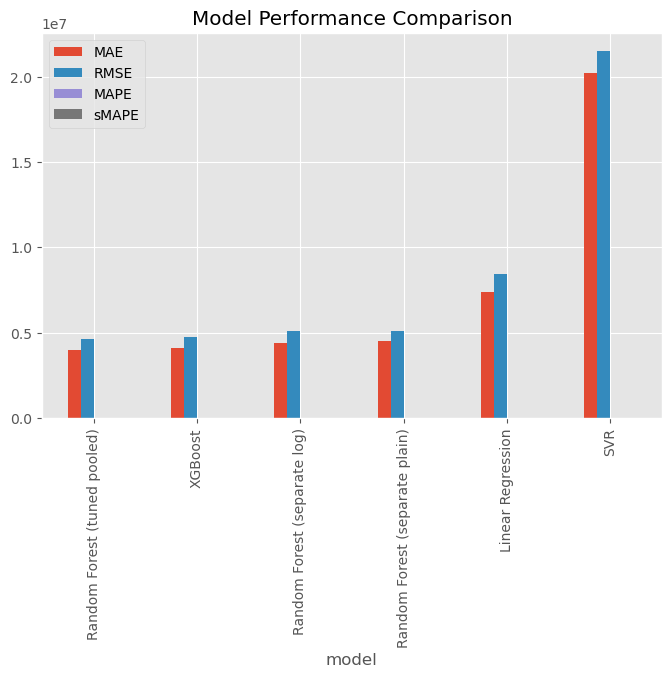

In [162]:
leaderboard.plot(kind="bar", figsize=(8,5))
plt.title("Model Performance Comparison")
plt.show()